# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import lisatools
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful
import h5py
import astropy

In [2]:
import matplotlib
from matplotlib.image import NonUniformImage

In [3]:
from scipy.stats import gmean

In [4]:
# imports 
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from lisatools.sensitivity import get_sensitivity

No CuPy or GPU PhenomHM module.
No CuPy or GPU interpolation available.


In [5]:
from bbhx.waveformbuild import BBHWaveformFD

No CuPy
No CuPy or GPU response available.


In [6]:
from eryn.prior import uniform_dist
from itertools import chain, repeat
import random

In [7]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.cosmology import z_at_value, Planck18, Planck13


In [8]:
# imports
from lisatools.sensitivity import AET1SensitivityMatrix
from lisatools.datacontainer import DataResidualArray
from lisatools.analysiscontainer import AnalysisContainer

In [9]:
import math
import pickle

# Blackhole Details File

In [10]:
merger_file="blackhole_mergers_tng300.hdf5"
merger_data=h5py.File(merger_file, 'r')
z=np.array(merger_data['time'])**(-1)-1
M_1=np.maximum(merger_data['mass_out'],merger_data['mass_in'])*1e10/.6774
M_2=np.minimum(merger_data['mass_out'],merger_data['mass_in'])*1e10/.6774

In [11]:
cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089, Tcmb0=2.725)
d_l=np.array(cosmo.luminosity_distance(z).value*1e6*PC_SI)

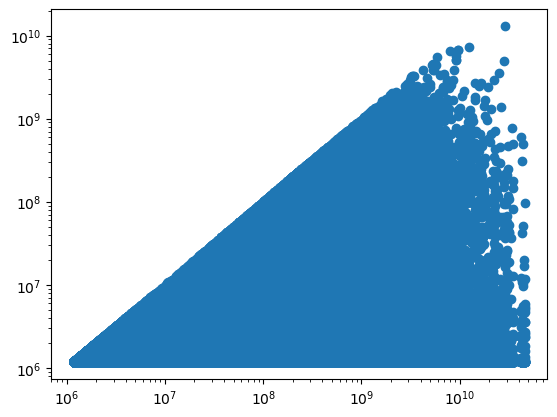

In [12]:
plt.loglog(M_1,M_2,'o')

# Defined Functions

In [ ]:
def x_mean_plotter(x, y, xbins=10, color='red', marker='o', plt_type=True, 
                   xgmean=True, ygmean=True, plot=True, label=None):
    
    start = min(x)
    stop = max(x)

    if xgmean:
        values = np.logspace(np.log10(start), np.log10(stop), xbins)
    else:
        values = np.linspace(start, stop, xbins)

    x_mean = []
    y_mean = []

    for i in range(len(values) - 1):
        mask_x = ((x > values[i]) & (x < values[i + 1]) & (~np.isnan(y)))
        x_slice = values[i:i+2]
        
        if xgmean:
            x_mean.append(gmean(x_slice))
        else:
            x_mean.append(np.mean(x_slice))
        
        y_values = y[mask_x]
        if len(y_values) > 0:  # Prevent errors from empty slices
            if ygmean:
                y_mean.append(gmean(y_values))
            else:
                y_mean.append(np.mean(y_values))
        else:
            y_mean.append(np.nan)  # Append NaN for empty bins
    
    if plot:
        if plt_type:
            plt.plot(x_mean, y_mean, color=color, marker=marker, label=label)
        else:
            plt.scatter(x_mean, y_mean, color=color, marker=marker, label=label)

    return x_mean, y_mean

: 

### Parameter Generation

In [ ]:
def random_pop(m1 = M_1, 
                m2 = M_2, dist = d_l, z=z, sample_size = 30000):

    # Generate random indices
    indices = random.sample(range(len(M_1)), sample_size)

    # Get elements from each array using the same indices
    M_1sample = np.array([m1[i] for i in indices])
    M_2sample = np.array([m2[i] for i in indices])
    d_lsample = np.array([dist[i] for i in indices])
    z_sample = np.array([z[i] for i in indices])
    
    
    result={
         'm1'  : M_1sample,
         'm2'  : M_2sample,
        'dist' : d_lsample,
        'z'    : z_sample
    }
    return result 


: 

In [ ]:
def draw_params(m1 = M_1, 
                m2 = M_2, dist = d_l,z=z,n=1): 
                
    arr_size=len(m1)*n
    
    znew = np.array(list(chain.from_iterable(repeat(x, n) for x in z)))
    m1new = np.array(list(chain.from_iterable(repeat(x, n) for x in m1)))*(znew+1)
    m2new = np.array(list(chain.from_iterable(repeat(x, n) for x in m2)))*(znew+1)
    distnew = np.array(list(chain.from_iterable(repeat(x, n) for x in dist)))
        

    # chi1 = np.full(arr_size, spin)
    # chi2 = np.full(arr_size, spin)
    
    phi_ref =  uniform_dist(0.0, 2 * np.pi).rvs(arr_size)
    f_ref = np.full(arr_size, 0)
    inc = np.arccos(uniform_dist(-1.0, 1.0).rvs(arr_size))
    lam = uniform_dist(0.0, 2 * np.pi).rvs(arr_size)
    beta = np.arcsin(uniform_dist(-1.0, 1.0).rvs(arr_size))
    psi = uniform_dist(0.0, np.pi).rvs(arr_size)
    t_ref = np.full(arr_size, 1e6)

    result={
         'm1'  : m1new,
         'm2'  : m2new,
         'z'   : znew,
        'dist' : distnew,
        # 'chi1':chi1,
        # 'chi2':chi2,
        'phi_ref': phi_ref,
        'f_ref': f_ref,
        'inc' : inc,
        'lam' : lam,
        'beta': beta,
        'psi' : psi,
        't_ref': t_ref,
        'num_elements':arr_size
    }
     
    return result

: 

In [ ]:
def avg_hist(x,y,z, bins=(20,20), c1='YlOrRd', c2= 'YlGnBu',  labelx=None, labely=None,
            labelz=None, norm1=matplotlib.colors.LogNorm(), logweight=True, 
            norm2=None, vmin=None,vmax=None):
 #            norm2=matplotlib.colors.LogNorm(vmin=None, vmax=None) ):
    z_mask=((~np.isnan(z))&(~np.isnan(x))&(~np.isnan(y)))
    x=x[z_mask]
    y=y[z_mask]
    z=z[z_mask]
    H_num, xedges, yedges = np.histogram2d(x, y, bins=bins)
    if logweight:
        z=np.log10(z)
    H_z, xedges, yedges = np.histogram2d(x,y, bins=(xedges, yedges), weights=z)
    H_num=H_num.T
    H_z=H_z.T
    plt.figure(figsize=(15,10))
    plt.subplot(2, 1, 1)
    plt.imshow(H_num, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
           cmap= c1, norm=norm1)
 
    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.colorbar(label='Numbers')

    plt.subplot(2,1,2)
    plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
               cmap=c2, norm=norm2, vmax=vmax,vmin=vmin)
    #print(np.min(H_z/H_num), np.max(H_z/H_num))
    #print(H_z/H_num)
   
    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.colorbar(label=labelz)
   
    
    plt.tight_layout()
    plt.gca().set_aspect('equal')


: 

### SNR Calculators

In [ ]:
arr_size = len(M_1)
tdi_wave_gen = BBHWaveformFD()

def wrap(*args, **kwargs):
    return tdi_wave_gen(*args, **kwargs)[0]

# def SNR_calc(m1 = M_1, m2 = M_2, dist = d_l, chi1 = np.full(arr_size, 0.5),
#              chi2 = np.full(arr_size, 0.7), phi_ref = np.full(arr_size, 0.6),
#              f_ref = np.full(arr_size, 0.0), inc = np.full(arr_size, np.pi / 8),
#              lam = np.full(arr_size, 0.5), beta = np.full(arr_size, -0.7),
#              psi = np.full(arr_size, np.pi / 4), t_ref = np.full(arr_size, 1e6),
#              num_elements = len(M_1),obs=1,z=z):
#     length = 1024

#     # Setup data holders
#     Tobs = YRSID_SI / 12*obs   # 1 month
#     dt = 10.0  # sec
#     N = int(Tobs / dt)
#     Tobs = N * dt

#     freqs = np.fft.rfftfreq(N, dt)
    
#     SNR_new = []

#     for i in range(num_elements):
#         AET_gen = tdi_wave_gen(
#             m1[i],
#             m2[i], 
#             chi1[i],
#             chi2[i],
#             dist[i], 
#             phi_ref[i],
#             f_ref[i], 
#             inc[i],
#             lam[i],
#             beta[i],
#             psi[i],
#             t_ref[i],
#             t_obs_start= t_ref[i] / YRSID_SI-obs/12,
#             t_obs_end=t_ref[i] / YRSID_SI+1/52,# need to change it 
#             length=1024, 
#             combine=False,  # TODO: check this
#             direct=False,
#             fill=True,
#             squeeze=True,
#             freqs=freqs
#         )
        
#         data = DataResidualArray(AET_gen[0], f_arr=freqs)
#         sens_mat = AET1SensitivityMatrix(data.f_arr)
#         analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
#         snr = analysis.snr()
#         SNR_new.append(snr)

#     return SNR_new


: 

In [ ]:
# def SNR_calc_opt(m1 = M_1, m2 = M_2, dist = d_l, chi1 = np.full(len(M_1), 0.0),
#     chi2 = np.full(len(M_1), 0.0),
#     phi_ref =  uniform_dist(0.0, 2 * np.pi).rvs(len(M_1)),
#     f_ref = np.full(len(M_1), 0),
#     inc = np.arccos(uniform_dist(-1.0, 1.0).rvs(len(M_1))),
#     lam = uniform_dist(0.0, 2 * np.pi).rvs(len(M_1)),
#     beta = np.arcsin(uniform_dist(-1.0, 1.0).rvs(len(M_1))),
#     psi = uniform_dist(0.0, np.pi).rvs(len(M_1)),
#     t_ref = np.full(len(M_1), 1e6),obs=1,
#     num_elements=len(M_1),batch=100):

#     #check if the length is same:
#     assert len(m1) == len(m2) == len(chi1) == len(chi2) == len(dist) == len(phi_ref) == len(f_ref) == len(inc) == len(lam) == len(beta) == len(psi) == len(t_ref), "Array lengths are not equal"
    
    
#     # Setup data holders
#     Tobs = YRSID_SI / 12*obs   # 1 month
#     dt = 10.0  # sec
#     N = int(Tobs / dt)
#     Tobs = N * dt

#     freqs = np.fft.rfftfreq(N, dt)
    
#     SNR_new = []

#     batch=batch
   
#     for i in range((num_elements + batch - 1) // batch):
#         start_i = i * batch
#         end_i = min((i + 1) * batch, num_elements)
        
#         AET_gen = tdi_wave_gen(
#             m1[start_i:end_i],
#             m2[start_i:end_i], 
#             chi1[start_i:end_i],
#             chi2[start_i:end_i],
#             dist[start_i:end_i], 
#             phi_ref[start_i:end_i],
#             f_ref[start_i:end_i], 
#             inc[start_i:end_i],
#             lam[start_i:end_i],
#             beta[start_i:end_i],
#             psi[start_i:end_i],
#             t_ref[start_i:end_i],
#             length=1024, 
#             combine=False,  # TODO: check this
#             direct=False,
#             fill=True,
#             squeeze=True,
#             freqs=freqs
#         )
#         for j in range(len(AET_gen)):
#             data = DataResidualArray(AET_gen[j], f_arr=freqs)
#             sens_mat = AET1SensitivityMatrix(data.f_arr)
#             analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
#             snr = analysis.snr()
#             SNR_new.append(snr)

#     return SNR_new

: 

In [ ]:
def SNR_calc_stoch(m1 = M_1, m2 = M_2, dist = d_l, chi1 = np.full(arr_size, 0.5),
             chi2 = np.full(arr_size, 0.7), phi_ref = np.full(arr_size, 0.6),
             f_ref = np.full(arr_size, 0.0), inc = np.full(arr_size, np.pi / 8),
             lam = np.full(arr_size, 0.5), beta = np.full(arr_size, -0.7),
             psi = np.full(arr_size, np.pi / 4), t_ref = np.full(arr_size, 0.5 * YRSID_SI),
             num_elements = len(M_1),obs=1,z=z,t_obs_end=1):
    length = 1024

    # Setup data holders
    Tobs = YRSID_SI / 12*obs    # 1 month
    dt = 10.0  # sec
    N = int(Tobs / dt)
    Tobs = N * dt

    freqs = np.fft.rfftfreq(N, dt)
    freqs=freqs[freqs>=10**(-4)]
    
    SNR_new = []

    for i in range(num_elements):
        AET_gen = tdi_wave_gen(
            m1[i],
            m2[i], 
            chi1[i],
            chi2[i],
            dist[i], 
            phi_ref[i],
            f_ref[i], 
            inc[i],
            lam[i],
            beta[i],
            psi[i],
            t_ref[i],
            t_obs_start=0,
            t_obs_end=t_obs_end,         
            length=1024, 
            combine=False,  # TODO: check this
            direct=False,
            fill=True,
            squeeze=True,
            freqs=freqs
        )
     
        data = DataResidualArray(AET_gen[0], f_arr=freqs)
        sens_mat = AET1SensitivityMatrix(data.f_arr,stochastic_params=(4.0 * YRSID_SI,))
        analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
        snr = analysis.snr()
        SNR_new.append(snr)

    return SNR_new

: 

In [ ]:
snr_i=SNR_calc_stoch(m1 = [1e6], m2 = [1e5], dist = [cosmo.luminosity_distance(3).value*1e6*PC_SI], chi1 = [0.8],
                            chi2 = [0.8], phi_ref =[0.6],
                            f_ref =[0.0], inc = [np.pi / 8],
                            lam =[0.5], beta =[-0.7],
                            psi =[4], t_ref = [1e7], t_obs_end=1,
                            num_elements = 1,z=3)
snr_i

[565.8080367353454]

: 

### New Function Testing

In [ ]:
draw_params()

{'m1': array([1.21589601e+07, 1.18869467e+07, 1.10221309e+07, ...,
        1.45095331e+08, 3.38200415e+08, 2.49824743e+09], shape=(590328,)),
 'm2': array([11679994.68407323, 11619418.60408496, 11018542.27018128, ...,
         2070850.01271595,  1181073.52076152,  1181029.87756243],
       shape=(590328,)),
 'z': array([8.181893e+00, 8.181893e+00, 8.173722e+00, ..., 7.402897e-05,
        7.402897e-05, 3.707409e-05], shape=(590328,), dtype=float32),
 'dist': array([2.60541360e+27, 2.60541360e+27, 2.60243443e+27, ...,
        1.01100302e+22, 1.01100302e+22, 5.06301150e+21], shape=(590328,)),
 'phi_ref': array([3.70109962, 5.63701539, 0.69986114, ..., 3.8636704 , 4.55068113,
        1.86107992], shape=(590328,)),
 'f_ref': array([0, 0, 0, ..., 0, 0, 0], shape=(590328,)),
 'inc': array([1.05863033, 0.87025266, 2.78954112, ..., 1.02673113, 1.9488726 ,
        1.99097266], shape=(590328,)),
 'lam': array([0.76875674, 5.95730547, 3.26889008, ..., 5.47908934, 2.21031134,
        0.1133036 ], s

: 

In [ ]:
Tobs = YRSID_SI / 12 # 1 month
dt = 10.0  # sec
N = int(Tobs / dt)
Tobs = N * dt

freqs = np.fft.rfftfreq(N, dt)

len(freqs[freqs>=10**(-4)])


131230

: 

## MBH waveform

In [14]:
def run_mbh(params):
    return tdi_wave_gen(
        params['m1'],
        params['m2'],
        params['chi1'],
        params['chi2'],
        params['dist'],
        params['phi_ref'],
        params['f_ref'],
        params['inc'],
        params['lam'],
        params['beta'],
        params['psi'],
        params['t_ref'],
        length=params.get('length', 1024),
        combine=params.get('combine', False),
        direct=params.get('direct', False),
        fill=params.get('fill', True),
        squeeze=params.get('squeeze', True),
        freqs=params['freqs']
    )


In [17]:
tdi_wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False))
def wrap(*args, **kwargs):
    return tdi_wave_gen(*args, **kwargs)[0]

bh=24
arr_size = 1

length = 1024

# setup data holders
Tobs =1.99/52* YRSID_SI   #3 weeks
dt = 10.0  # sec
N = int(Tobs / dt)
Tobs = N * dt
SNR_new=[]
freqs = np.fft.rfftfreq(N, dt)
freqs=freqs[freqs>=10**(-4)]

parameter = {
    'm1': m1_j[bh],
    'm2': m2_j[bh],
    'dist': d_l_j[bh] * 1e9 * PC_SI,  # Convert Gpc to meters
    'chi1': np.full(arr_size, 0.0),
    'chi2': np.full(arr_size, 0.0),
    'phi_ref': uniform_dist(0.0, 2 * np.pi).rvs(arr_size),
    'f_ref': np.full(arr_size, 0),
    'inc': np.arccos(uniform_dist(-1.0, 1.0).rvs(arr_size)),
    'lam': uniform_dist(0.0, 2 * np.pi).rvs(arr_size),
    'beta': np.arcsin(uniform_dist(-1.0, 1.0).rvs(arr_size)),
    'psi': uniform_dist(0.0, np.pi).rvs(arr_size),
    't_ref': np.full(arr_size, 2 * 7 * 24 * 3600),  # 2 weeks in seconds
    'length': 1024,
    'combine': False,
    'direct': False,
    'fill': True,
    'squeeze': True,
    'freqs': freqs
}


AET_gen = run_mbh(parameter)
data = DataResidualArray(AET_gen[0], f_arr=freqs)
sens_mat = AET1SensitivityMatrix(data.f_arr,stochastic_params=(4.0 * YRSID_SI,))
analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
snr = analysis.snr()
       

(1e-05, 0.01)

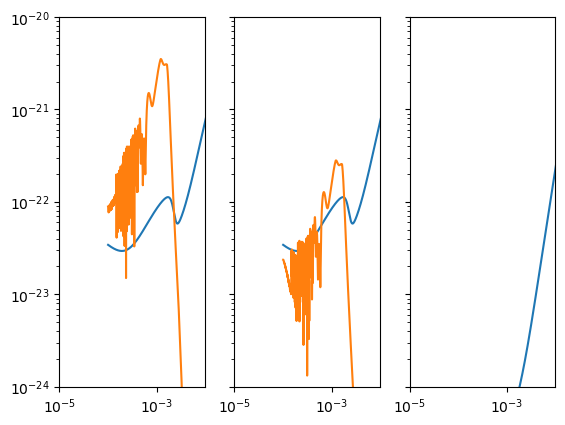

In [19]:
analysis.loglog()
plt.ylim(1e-24,1e-20)
plt.xlim(1e-5,1e-2)

In [ ]:
from numpy.fft import irfft

# Suppose AET_gen[0] is a 3×N complex array for A, E, T channels in frequency domain
AET_fd = AET_gen[0]  # shape: (3, len(freqs))
# Inverse FFT to time domain
# You need to provide the full length of the time domain series (N)
AET_td = irfft(AET_fd, n=N, axis=1)  #shape: (3, N)

In [23]:
import emri_utils
from emri_utils import emri_waveform
import importlib
importlib.reload(emri_utils)

<module 'emri_utils' from '/home/karmakar/SMBH-Merger-SNR-calculation-with-LISA/emri_utils.py'>

/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/few/utils/baseclasses.py:416: UserWarning: Mass ratio is outside of generally accepted range for an extreme mass ratio (1e-4). (q=0.00894852)
  warnings.warn(


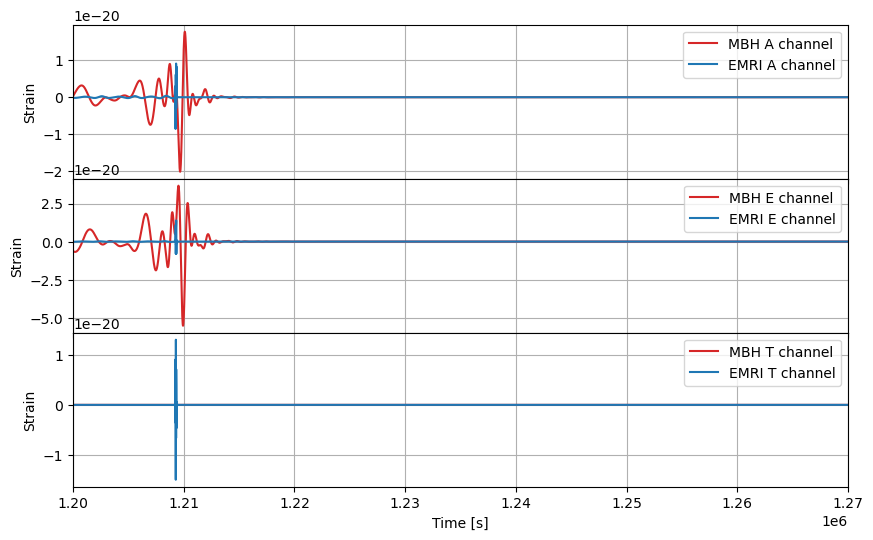

<Figure size 640x480 with 0 Axes>

In [38]:
time_arr = np.linspace(0, Tobs, N)
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 6), gridspec_kw={'hspace': 0})

# Plot the first waveform (AET_td)
labels = ['A channel', 'E channel', 'T channel']
colors = ['tab:red', 'tab:red', 'tab:red']
for i in range(3):
    axes[i].plot(time_arr, AET_td[i].real, color=colors[i], ls='-', label=f'MBH {labels[i]}')
    axes[i].set_ylabel('Strain')
    axes[i].legend()
    axes[i].grid(True)
    axes[i].set_xlim(1.2e6,1.27e6)

axes[-1].set_xlabel('Time [s]')

# Overlay the EMRI waveform on the same axes
emri_waveform(new_pars, axes=axes)
# plt.xlim(1e6,1.2e6)


plt.tight_layout()
plt.show()


In [34]:
data = np.load("parameters.npz")
new_pars = dict(data)

: 

In [ ]:
new_pars
new_pars['mu']=1e5
new_pars['M']=1e6
print(new_pars)

{'T': array(0.03846154), 'dt': array(10), 'M': 1000000.0, 'a': array(0.), 'mu': 100000.0, 'p0': array(13.15003204), 'e0': array(0), 'x0': array(1.), 'qK': array(0.), 'phiK': array(0), 'qS': array(0.3), 'phiS': array(0.3), 'dist': array(15.12361353), 'Phi_phi0': array(0.), 'Phi_theta0': array(0.), 'Phi_r0': array(0.)}


: 

/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/few/utils/baseclasses.py:416: UserWarning: Mass ratio is outside of generally accepted range for an extreme mass ratio (1e-4). (q=0.00894852)
  warnings.warn(


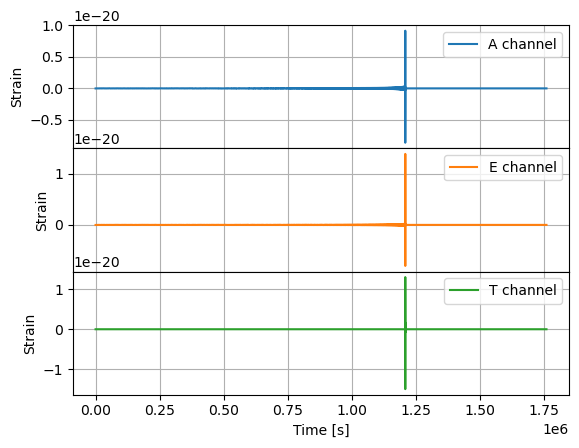

: 

In [ ]:
fig, axes= emri_waveform(new_pars)

In [25]:
not_z=np.argmax(AET_gen[0][0][::-1]!=0)

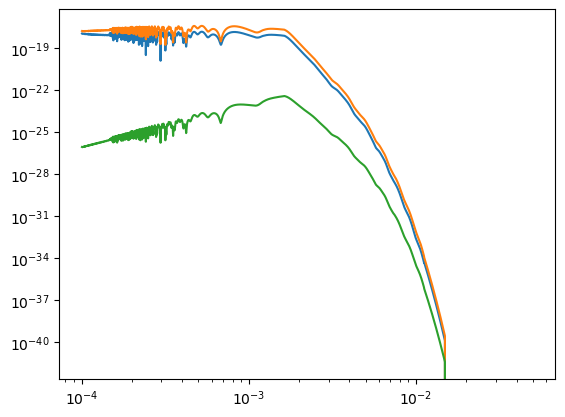

In [33]:
for i, let in enumerate(["A", "E", "T"]):
    plt.loglog(freqs, np.abs(AET_gen[0][i]), label=let)

(0.0001, 0.1)

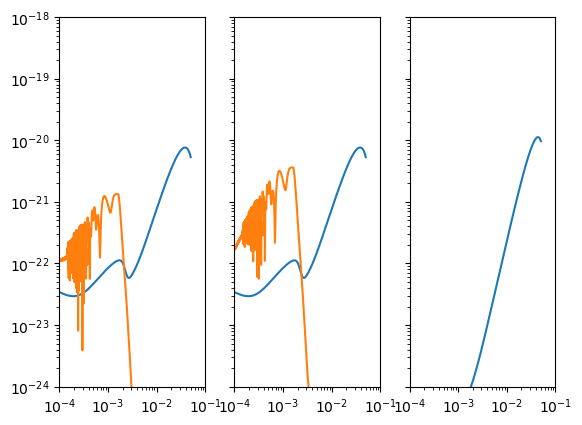

In [42]:
analysis.loglog()
plt.ylim(1e-24,1e-18)
plt.xlim(1e-4,1e-1)

In [27]:
print(not_z)

77257


In [28]:
len(AET_gen[0][0])

90851

In [29]:
wave_gen = BBHWaveformFD()

Text(0, 0.5, '$\\tilde{h}(f)$ (Hz$^{-1/2}$)')

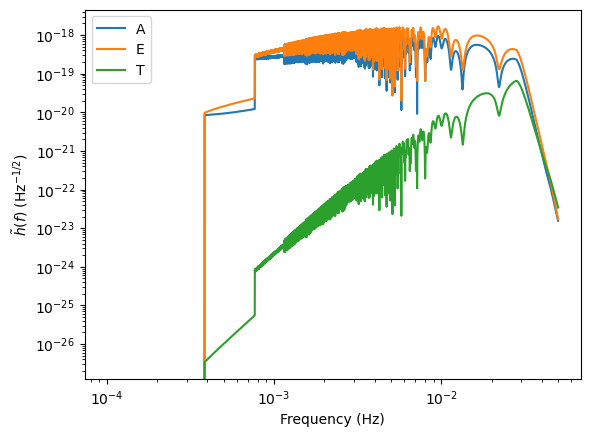

In [30]:
# set parameters
f_ref = 0.0  # let phenom codes set f_ref -> fmax = max(f^2A(f))
phi_ref = 0.0 # phase at f_ref
m1 = 1e6
m2 = 1e4
a1 = 0.2
a2 = 0.4
dist = 18e3  * PC_SI * 1e6 # 3e3 in Mpc
inc = np.pi/3.
beta = np.pi/4.  # ecliptic latitude
lam = np.pi/5.  # ecliptic longitude
psi = np.pi/6.  # polarization angle
t_ref = 2*7*3600*24 # t_ref  (in the SSB reference frame)

# frequencies to interpolate to
freq_new = np.logspace(-4, 0, 10000)
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

Tobs =3/52* YRSID_SI   #3 weeks
dt = 10.0  # sec
N = int(Tobs / dt)
Tobs = N * dt
SNR_new=[]
freqs = np.fft.rfftfreq(N, dt)
freqs=freqs[freqs>=10**(-4)]

wave = wave_gen(m1, m2, a1, a2,
                          dist, phi_ref, f_ref, inc, lam,
                          beta, psi, t_ref, freqs=freqs,
                          modes=modes, direct=False, fill=True, squeeze=True, length=1024)[0]

for i, let in enumerate(["A", "E", "T"]):
    plt.loglog(freqs, np.abs(wave[i]), label=let)
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$\tilde{h}(f)$ (Hz$^{-1/2}$)")



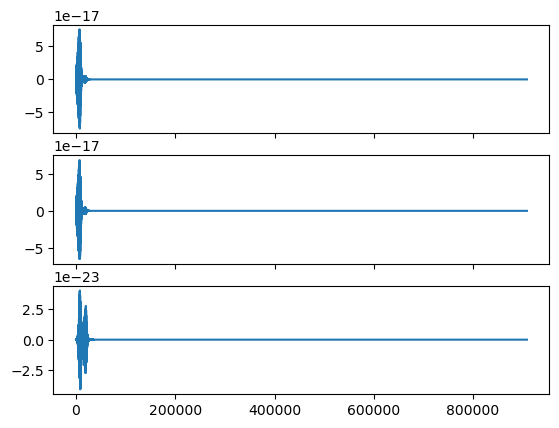

: 

In [ ]:
fig, ax = plt.subplots(3, 1, sharex=True)

for i in range(3):
    
    ax[i].plot(np.arange(len(AET_gen[0][i]))* dt, AET_gen[0][i].real)
   

# Analysis
 

Loading Calculations

In [ ]:

snr_tng300=np.load('snr_tng300.npy')
snr_tng300_old=np.load('snr_tng300_old.npy')

: 

In [ ]:
# reduced_M_1=np.load('M1_mass_fact.npy')
# reduced_M_2=np.load('M2_mass_fact.npy')

: 

##### Plots


Text(0, 0.5, 'SNR')

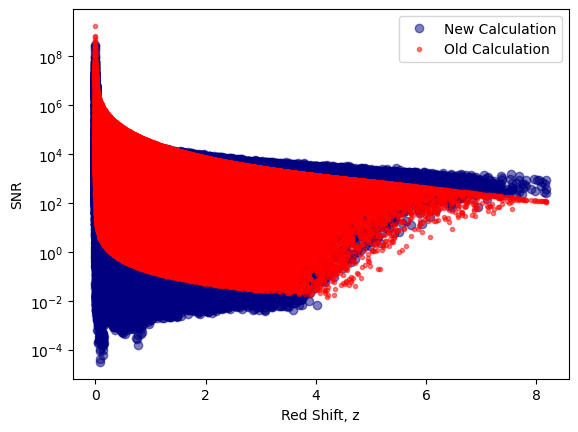

: 

In [ ]:
plt.plot(z,snr_tng300,'o',alpha=.5,c='navy',label='New Calculation')
plt.plot(z,snr_tng300_old,'.',alpha=.5,c='red',label='Old Calculation')
plt.yscale('log')
plt.legend()
plt.xlabel('Red Shift, z')
plt.ylabel('SNR')

Text(0, 0.5, 'SNR')

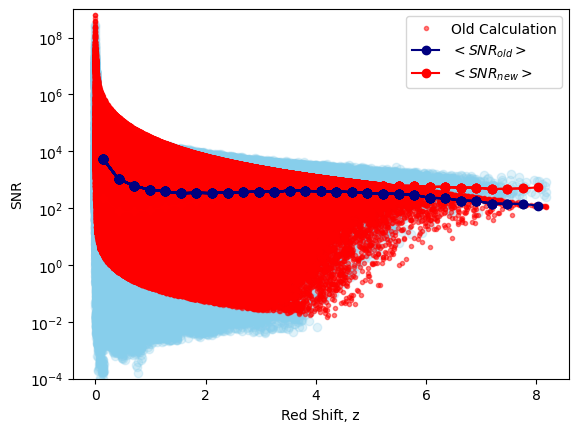

: 

In [ ]:
plt.plot(z,snr_tng300,'o',alpha=.25,c='skyblue')
plt.plot(z,snr_tng300_old,'.',alpha=.5,c='red',label='Old Calculation')
avg_x1, avg_y1=x_mean_plotter(z, snr_tng300 ,xgmean=False,xbins=30)
avg_x2, avg_y2=x_mean_plotter(z, snr_tng300_old,xgmean=False,xbins=30,color='Navy')

plt.plot(1,10**20,label='$<SNR_{old}>$', marker='o',c='navy')
plt.plot(1,10**20,label='$<SNR_{new}>$', marker='o',c='r')


plt.ylim(1e-4,1e9)

plt.yscale('log')
plt.legend()
plt.xlabel('Red Shift, z')
plt.ylabel('SNR')

In [ ]:
# fn = np.logspace(-6, -1, 10000)
# Sn_char_strain = get_sensitivity(fn, sens_fn="A1TDISens", return_type="char_strain")
# plt.loglog(fn, Sn_char_strain)
# plt.loglog(freqs, freqs * np.abs(wave_AET[0,1]),label='A')
# plt.loglog(freqs, freqs * np.abs(wave_AET[1,1]),label='E')
# plt.loglog(freqs, freqs * np.abs(wave_AET[2,1]), label='T')
# plt.legend()

: 

In [ ]:
# snr_tng50=[]
# for i in range(700):
#     data = DataResidualArray(wave_AET[i], f_arr=freqs)
#     sens_mat = AET1SensitivityMatrix(data.f_arr)
#     analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
#     snr=analysis.snr()
#     snr_tng50.append(snr)
#     #print(snr_tng50)


: 

/tmp/ipykernel_3522/1729027610.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Error in callback <function _draw_all_if_interactive at 0x7f027a82bb00> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

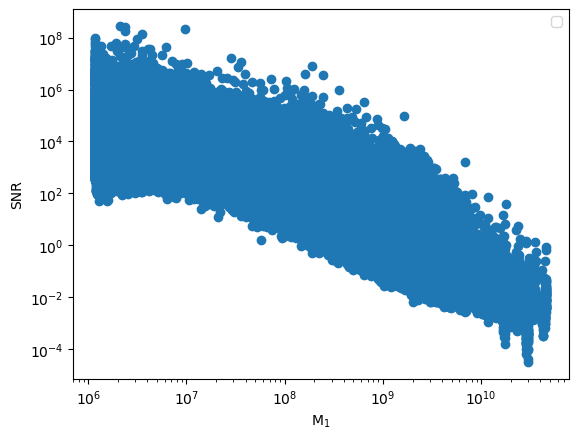

: 

In [ ]:
plt.loglog(M_1,snr_tng300,'o')
#plt.loglog(M_1,snr_tng50,'o',label='Fixed Parameters')
plt.xlabel('M$_1$')
plt.ylabel('SNR')
plt.legend()

<function matplotlib.pyplot.savefig(*args, **kwargs) -> 'None'>

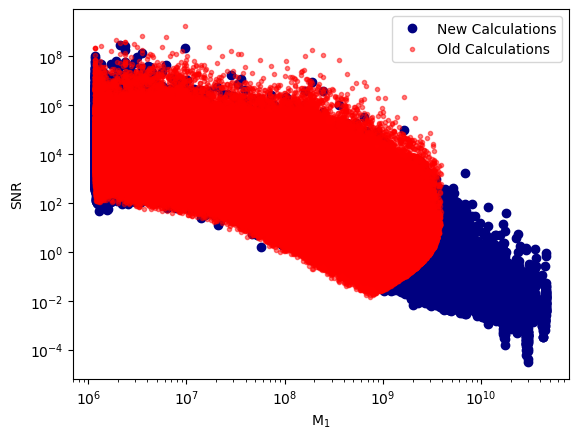

: 

In [ ]:
plt.loglog(M_1,snr_tng300,'o',label='New Calculations',c='navy')
plt.loglog(M_1,snr_tng300_old,'.',label='Old Calculations', c='red',alpha=.5)
plt.xlabel('M$_1$')
plt.ylabel('SNR')
plt.legend()
plt.savefig

Mask

In [ ]:
snr_tng300=np.array(snr_tng300)
mask=(snr_tng300>1)

: 

##### 2d Histograms

/tmp/ipykernel_2027/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


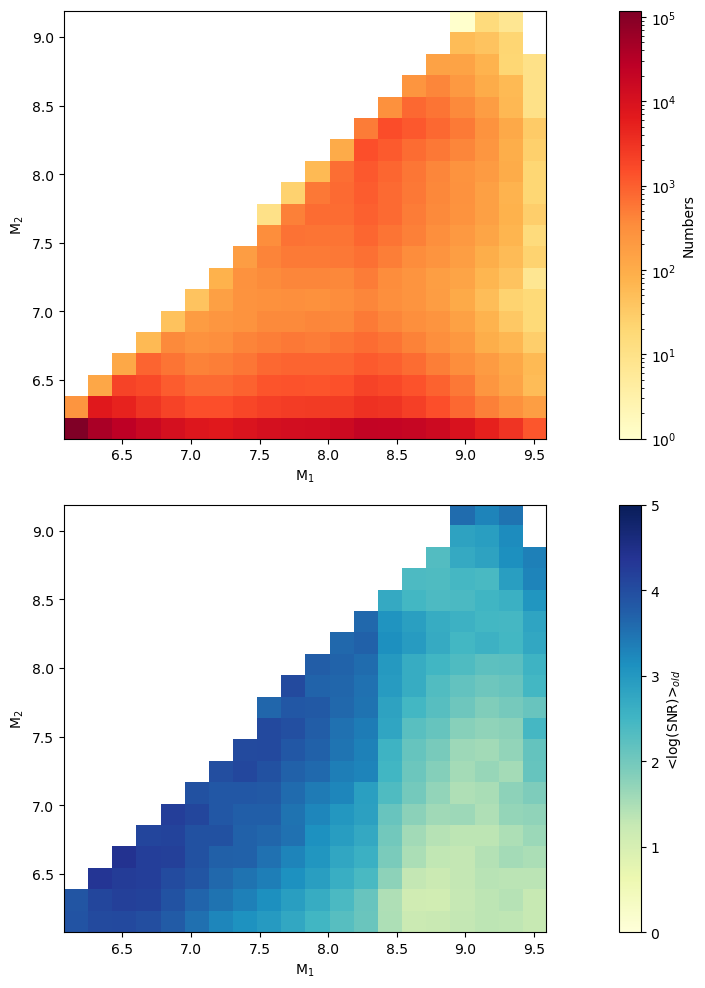

: 

In [ ]:
avg_hist(np.log10(M_1[mask]), np.log10(M_2[mask]),snr_tng300_old[mask],labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>$_{old}$', logweight=True,vmin=0,vmax=5)
#plt.savefig('avg_hist_m1m2snr_o.png', dpi=300)

/tmp/ipykernel_2027/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


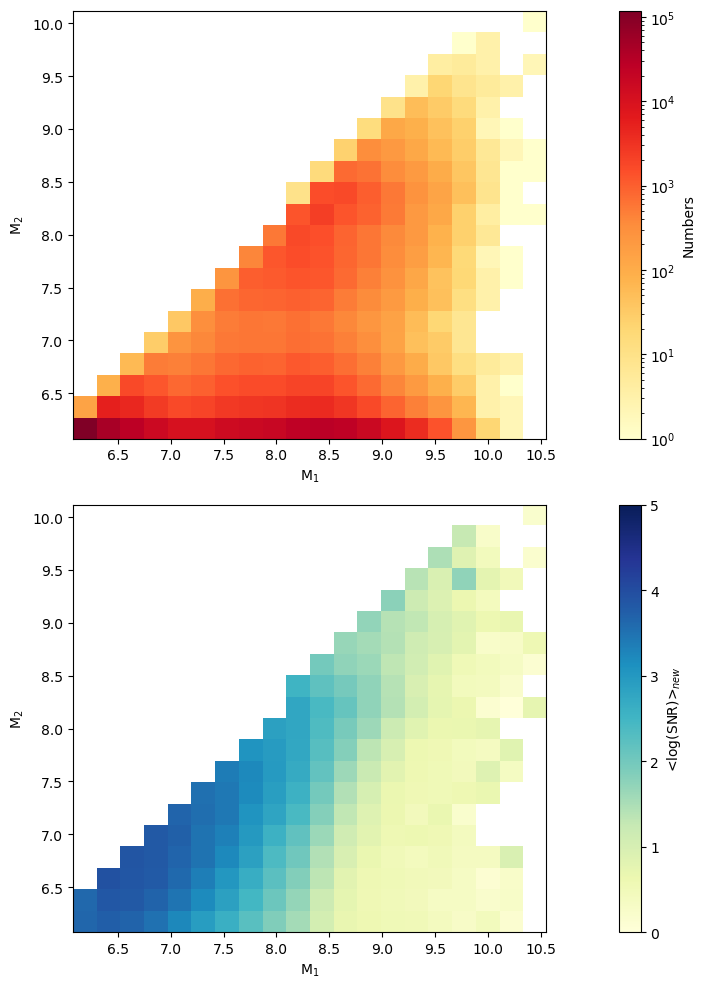

: 

In [ ]:
avg_hist(np.log10(M_1[mask]), np.log10(M_2[mask]),snr_tng300[mask],labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>$_{new}$', logweight=True,vmin=0,vmax=5)
#plt.savefig('avg_hist_m1m2snr_n.png', dpi=300)

/tmp/ipykernel_2027/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


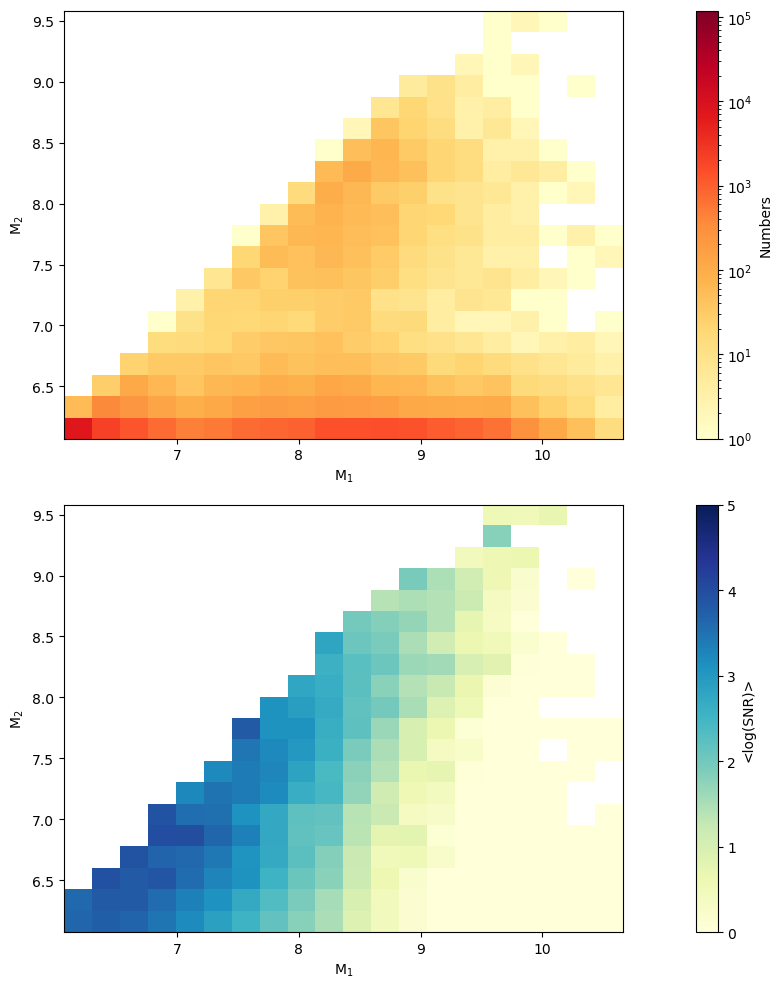

: 

In [ ]:
sample_size = 30000
# Generate random indices
indices = random.sample(range(len(M_1)), sample_size)

# Get elements from each array using the same indices
M_1sample = np.array([M_1[i] for i in indices])
M_2sample = np.array([M_2[i] for i in indices])
SNR_sample = np.array([snr_tng300[i] for i in indices])
reduced_M_1sample=np.array([M_1[i] for i in indices])
reduced_M_2sample=np.array([M_2[i] for i in indices])
d_lsample = np.array([d_l[i] for i in indices])
avg_hist(np.log10(M_1sample),np.log10(M_2sample),SNR_sample,labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

In [ ]:
# sample_params=draw_params(m1=M_1sample, m2=M_2sample,dist=d_lsample)
# sample_reduced_params=draw_params(m1=reduced_M_1sample, m2=reduced_M_2sample,dist=d_lsample)

: 

In [ ]:
# snr_sample=SNR_calc(**sample_params)
# snr_reduced_sample=SNR_calc(**sample_reduced_params)

: 

In [ ]:
# np.save('snr_sample.npy', snr_sample)
# np.save('snr_reduced_sample.npy', snr_reduced_sample)

: 

In [ ]:
# avg_hist(np.log10(M_1sample),np.log10(M_2sample),np.array(snr_reduced_sample)/np.array(snr_sample),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True)#,vmin=0,vmax=5)

: 

In [ ]:
# rand_pop_3=random_pop(sample_size=1000)
# rand_draw_3=draw_params(**rand_pop_3)

# snr_random_pop3_obs_1=SNR_calc(**rand_draw_3)
# snr_random_pop3_obs_3=SNR_calc(**rand_draw_3,obs=3)

# rand_pop_3_M1=np.array(rand_draw_3['m1'])
# rand_pop_3_M2=np.array(rand_draw_3['m2'])
# rand_pop_3_z=np.array(rand_draw_3['z'])

: 

In [ ]:

# avg_hist(np.log10(rand_pop_3_M1),np.log10(rand_pop_3_M2),np.array(snr_random_pop3_obs_1),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

: 

In [ ]:

# avg_hist(np.log10(rand_pop_3_M1),np.log10(rand_pop_3_M2),np.array(snr_random_pop3_obs_3),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

: 

In [ ]:

# avg_hist(np.log10(rand_pop_3_M1),np.log10(rand_pop_3_M2),np.array(snr_random_pop3_obs_3)/np.array(snr_random_pop3_obs_1),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

: 

In [ ]:
# rand_pop_2=random_pop(sample_size=30000)
# rand_draw_2=draw_params(**rand_pop_2)

: 

In [ ]:
# snr_random_pop3_obs_1

: 

In [ ]:
# snr_random_pop3_obs_3

: 

In [ ]:
# rand_pop_2_M1=np.array(rand_draw_2['m1'])
# rand_pop_2_M2=np.array(rand_draw_2['m2'])

: 

In [ ]:
# rand_pop_2_z=np.array(rand_draw_2['z'])

: 

In [ ]:
# snr_random_pop2_obs_1=SNR_calc(**rand_draw_2)

: 

In [ ]:
rand_pop_2_M1=np.load('rand_pop_2_M1.npy')
rand_pop_2_M2=np.load('rand_pop_2_M2.npy')
rand_pop_2_z=np.load('rand_pop_2_z.npy')
snr_random_pop2_obs_1=np.load('snr_random_pop2_obs_1.npy')
snr_random_pop2_obs_3=np.load('snr_random_pop2_obs_3.npy')
snr_random_pop2_obs_6=np.load('snr_random_pop2_obs_6.npy')
snr_random_pop2_obs_12=np.load('snr_random_pop2_obs_12.npy')


: 

/tmp/ipykernel_2027/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


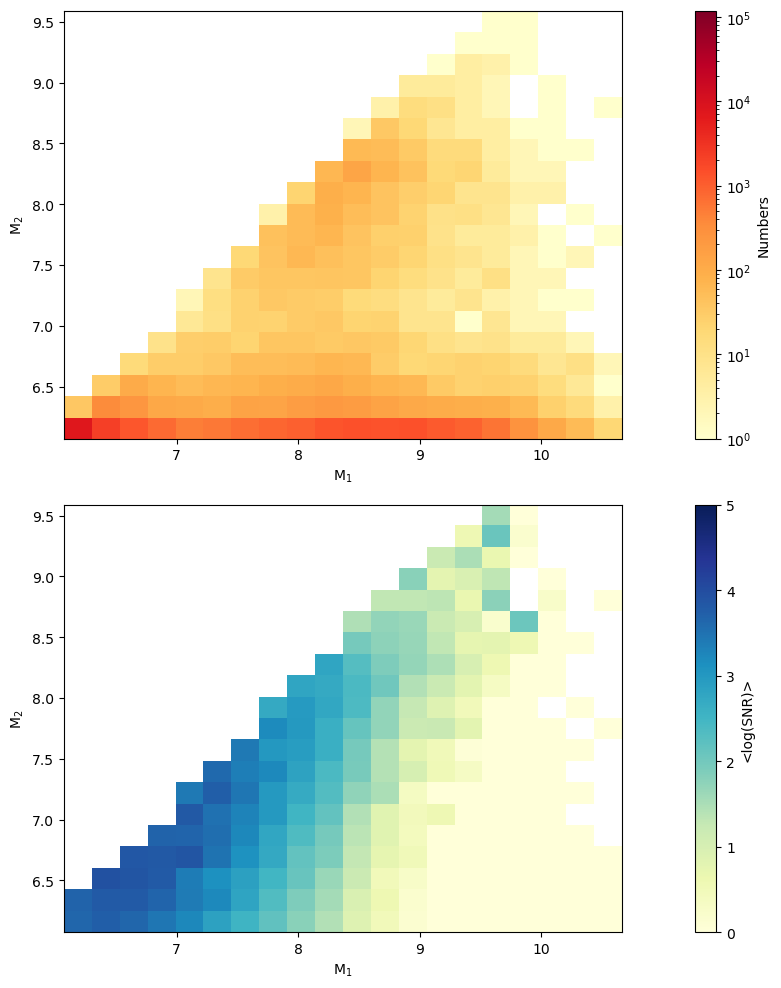

: 

In [ ]:

avg_hist(np.log10(rand_pop_2_M1),np.log10(rand_pop_2_M2),np.array(snr_random_pop2_obs_1),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

In [ ]:
# snr_test_opt=SNR_calc_opt(**rand_draw_1)

: 

In [ ]:
# snr_random_pop2_obs_3=SNR_calc(**rand_draw_2,obs=3)

: 

/tmp/ipykernel_2027/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


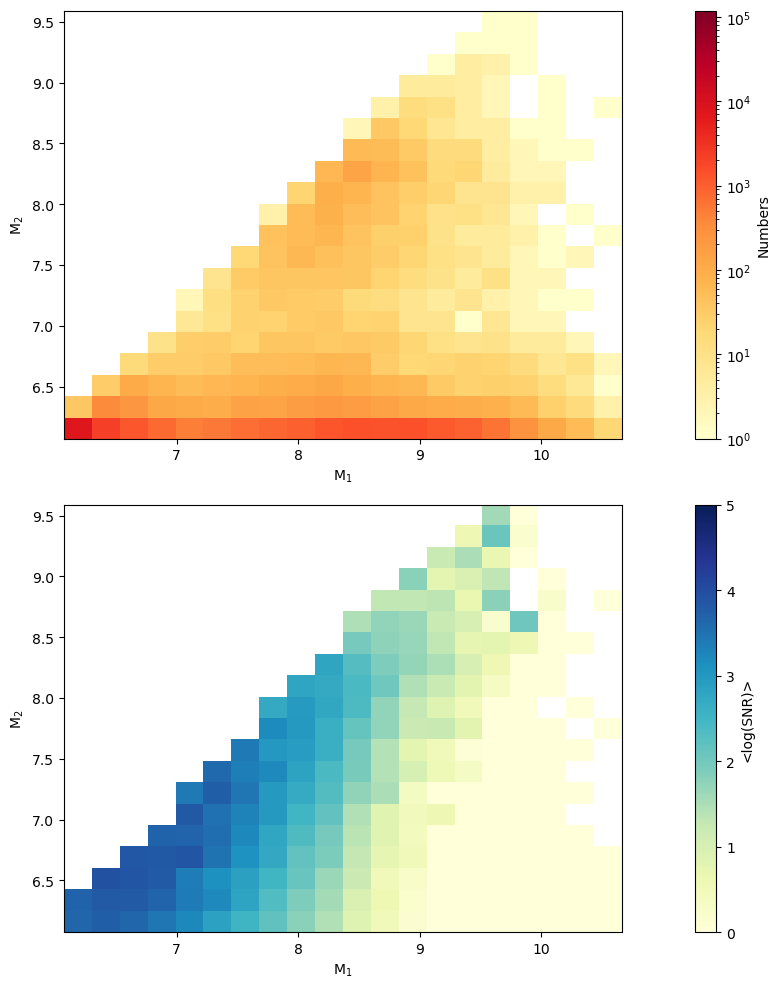

: 

In [ ]:
avg_hist(np.log10(rand_pop_2_M1),np.log10(rand_pop_2_M2),np.array(snr_random_pop2_obs_3),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

In [ ]:
# snr_random_pop2_obs_6=SNR_calc(**rand_draw_2,obs=6)

: 

/tmp/ipykernel_2027/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


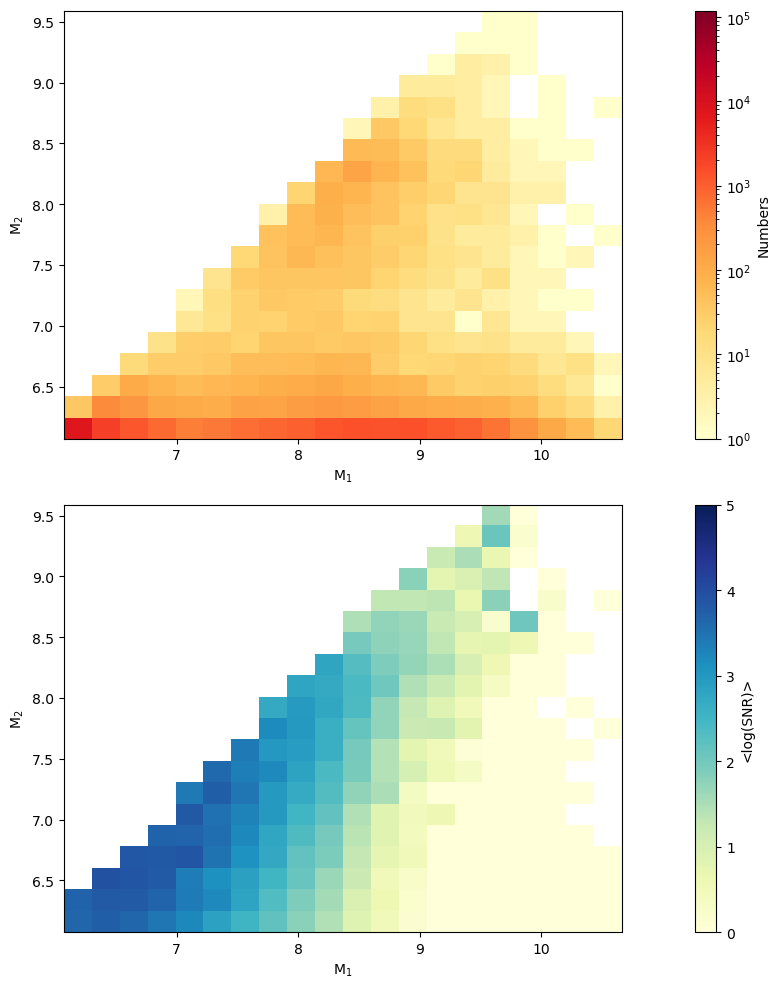

: 

In [ ]:
avg_hist(np.log10(rand_pop_2_M1),np.log10(rand_pop_2_M2),np.array(snr_random_pop2_obs_6),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

In [ ]:
# snr_random_pop2_obs_12=SNR_calc(**rand_draw_2,obs=12)


: 

/tmp/ipykernel_2027/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


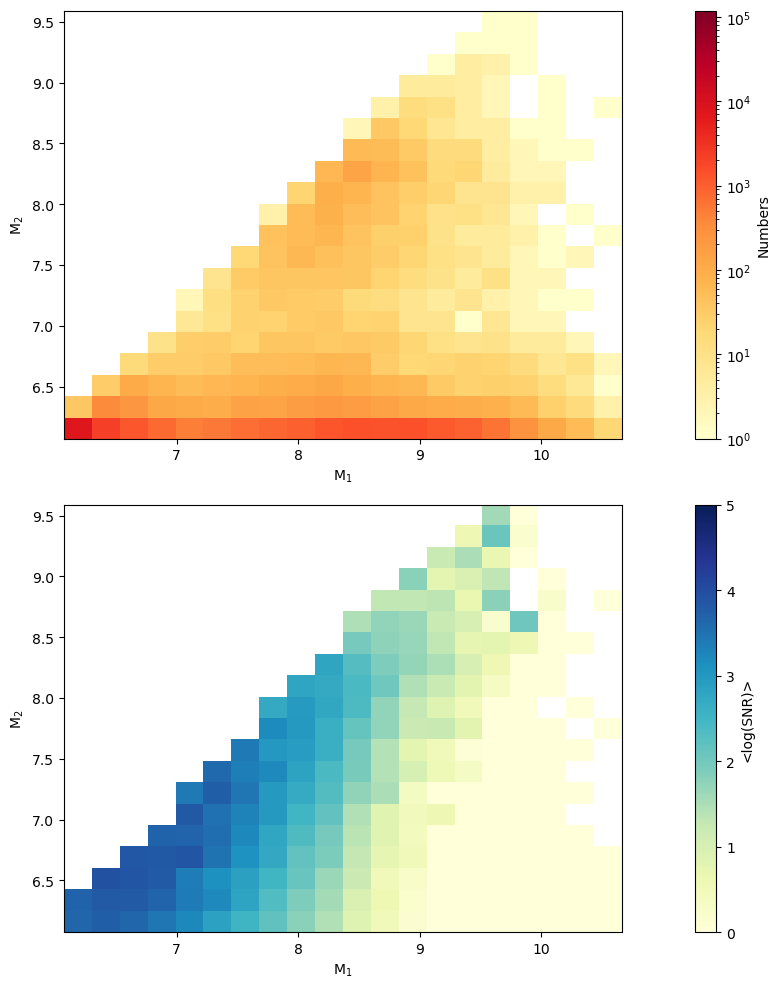

: 

In [ ]:
avg_hist(np.log10(rand_pop_2_M1),np.log10(rand_pop_2_M2),np.array(snr_random_pop2_obs_12),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

In [ ]:
# np.save('snr_random_pop2_obs_1.npy',snr_random_pop2_obs_1)
# np.save('snr_random_pop2_obs_3.npy',snr_random_pop2_obs_3)
# np.save('snr_random_pop2_obs_6.npy',snr_random_pop2_obs_6)
# np.save('snr_random_pop2_obs_12.npy',snr_random_pop2_obs_12)
# np.save('rand_pop_2_M1.npy',rand_pop_2_M1)
# np.save('rand_pop_2_M2.npy',rand_pop_2_M2)

: 

In [ ]:
# np.save('rand_pop_2_z.npy',rand_pop_2_z)

: 

/tmp/ipykernel_2027/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


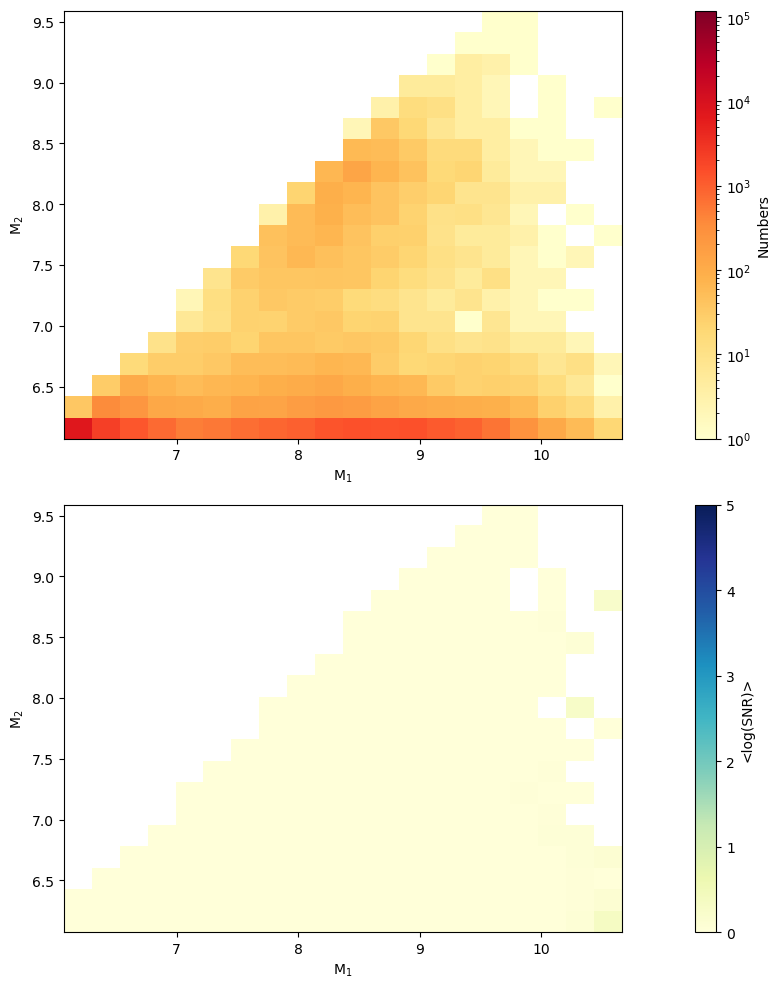

: 

In [ ]:
avg_hist(np.log10(rand_pop_2_M1),np.log10(rand_pop_2_M2),np.array(snr_random_pop2_obs_12)/np.array(snr_random_pop2_obs_1),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

In [ ]:
# np.save('snr_random_pop1_obs_1.npy',snr_random_pop1_obs_1)
# np.save('snr_random_pop1_obs_3.npy',snr_random_pop1_obs_3)
# np.save('snr_random_pop1_obs_6.npy',snr_random_pop1_obs_6)

: 

In [ ]:
np.array(snr_random_pop2_obs_12)


array([ 2208.0333186 ,  2076.6499864 ,  1997.78832475, ...,
         363.07895325,  7923.22334395, 21651.74595167])

: 

In [ ]:
np.array(snr_random_pop2_obs_1)


array([ 2208.03352175,  2076.64997517,  1997.78831307, ...,
         363.07871382,  7923.22260077, 21651.7458776 ])

: 

In [ ]:
# snr_random_pop1_obs_1=np.load('snr_random_pop1_obs_1.npy')
# snr_random_pop1_obs_3=np.load('snr_random_pop1_obs_3.npy')
# snr_random_pop1_obs_6=np.load('snr_random_pop1_obs_6.npy')

: 

In [ ]:
# rand_pop_1_M1=rand_draw_1['m1']
# rand_pop_1_M2=rand_draw_1['m2']

# plt.loglog(rand_pop_1_M1,snr_random_pop1_obs_1,'o')
# plt.loglog(rand_pop_1_M1,snr_random_pop1_obs_3,'o')
# plt.loglog(rand_pop_1_M1,snr_random_pop1_obs_6,'o')
# #plt.loglog(M_1,snr_tng50,'o',label='Fixed Parameters')
# plt.xlabel('M$_1$')
# plt.ylabel('SNR')
# plt.legend()

: 

In [ ]:
# avg_hist(np.log10(rand_pop_1_M1),np.log10(rand_pop_1_M2),snr_random_pop1_obs_1,labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

: 

In [ ]:
# avg_hist(np.log10(rand_pop_1_M1),np.log10(rand_pop_1_M2),snr_random_pop1_obs_3,labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

: 

In [ ]:
# avg_hist(np.log10(rand_pop_1_M1),np.log10(rand_pop_1_M2),snr_random_pop1_obs_6,labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

: 

## Small Mass

In [ ]:
# random_pop(m1=reduced_M_1,m2=reduced_M_2)

: 

In [ ]:
# reduced_random_pop1=draw_params(**random_pop(m1=reduced_M_1,m2=reduced_M_2))

: 

In [ ]:
# snr_reduced=SNR_calc(**reduced_random_pop1)

: 

In [ ]:
# rand_reduced_M_1=reduced_random_pop1['m1']
# rand_reduced_M_2=reduced_random_pop1['m2']

: 

In [ ]:
# avg_hist(np.log10(rand_reduced_M_1),np.log10(rand_reduced_M_2),np.array(snr_reduced),labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>', logweight=True,vmin=0,vmax=5)

: 

# Galaxy Foreground Noise

In [ ]:
m1 = 2e6
m2 = 7e5
chi1 = 0.5
chi2 = 0.7
dist = 15 * 1e9 * PC_SI
phi_ref = 0.6
f_ref = 0.0
inc = np.pi / 8
lam = 3.4
beta = -0.7
psi = np.pi/4
t_ref = 1e6 # seconds

length = 1024

# setup data holders
Tobs = YRSID_SI / 12.  # 1 month
dt = 10.0  # sec
N = int(Tobs / dt)
Tobs = N * dt

freqs = np.fft.rfftfreq(N, dt)

AET = tdi_wave_gen(
    m1,
    m2, 
    chi1,
    chi2,
    dist, 
    phi_ref,
    f_ref, 
    inc,
    lam,
    beta,
    psi,
    t_ref,
    length=1024, 
    combine=False,  # TODO: check this
    direct=False,
    fill=True,
    squeeze=True,
    freqs=freqs
)

: 

(1e-06, 0.1)

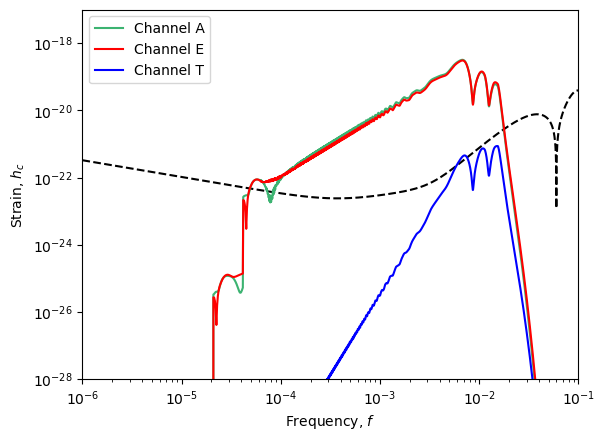

: 

In [ ]:
fn = np.logspace(-6, -1, 10000) #use -4
Sn_char_strain = get_sensitivity(fn, sens_fn="E1TDISens", return_type="char_strain")
plt.loglog(fn, Sn_char_strain,'--', c='black')
plt.loglog(1e-3,1e-20,c='navy')



plt.loglog(freqs, freqs * np.abs(AET[0,0]),c='mediumseagreen',label='Channel A' )
plt.loglog(freqs, freqs * np.abs(AET[0,1]),c='red',label='Channel E')
plt.loglog(freqs, freqs * np.abs(AET[0,2]),c='b',label='Channel T')
plt.xlabel('Frequency, $f$')
plt.ylabel('Strain, $h_c$')
plt.legend()
plt.ylim(1e-28,1e-17)
plt.xlim(1e-6,1e-1)

In [ ]:
def wrap(*args, **kwargs):
    return tdi_wave_gen(*args, **kwargs)[0]

: 

In [ ]:
from lisatools.sensitivity import SensitivityMatrix, LISASens, A1TDISens, E1TDISens

: 

In [ ]:
data = DataResidualArray(AET[0], f_arr=freqs)
sens_mat = AET1SensitivityMatrix(data.f_arr,stochastic_params=(4.0 * YRSID_SI,))

analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)

/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:83: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:85: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:87: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:92: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:94: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi *

: 

In [ ]:
analysis.snr()

2969.650813925918

: 

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

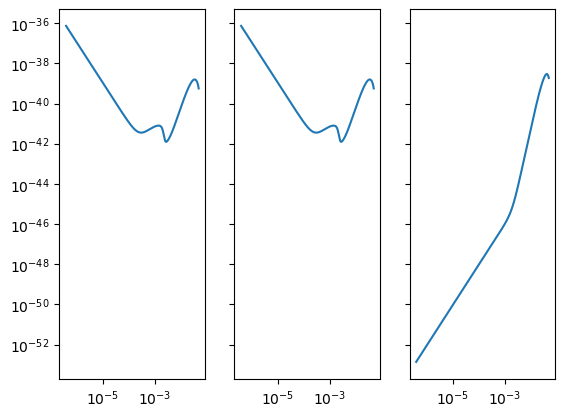

: 

In [ ]:
sens_mat.loglog()

In [ ]:
# pop_1 = draw_params()

: 

In [ ]:
# snr_tng300_stoch=SNR_calc_stoch(**pop_1)
# np.save('snr_tng300_stoch.npy',snr_tng300_stoch)
snr_tng300_stoch=np.load('snr_tng300_stoch.npy')

: 

In [ ]:
# testM1=pop_1['m1']
# testM2=pop_1['m2']


: 

In [ ]:
# np.save('pop_1.npy',pop_1)

: 

/tmp/ipykernel_2027/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


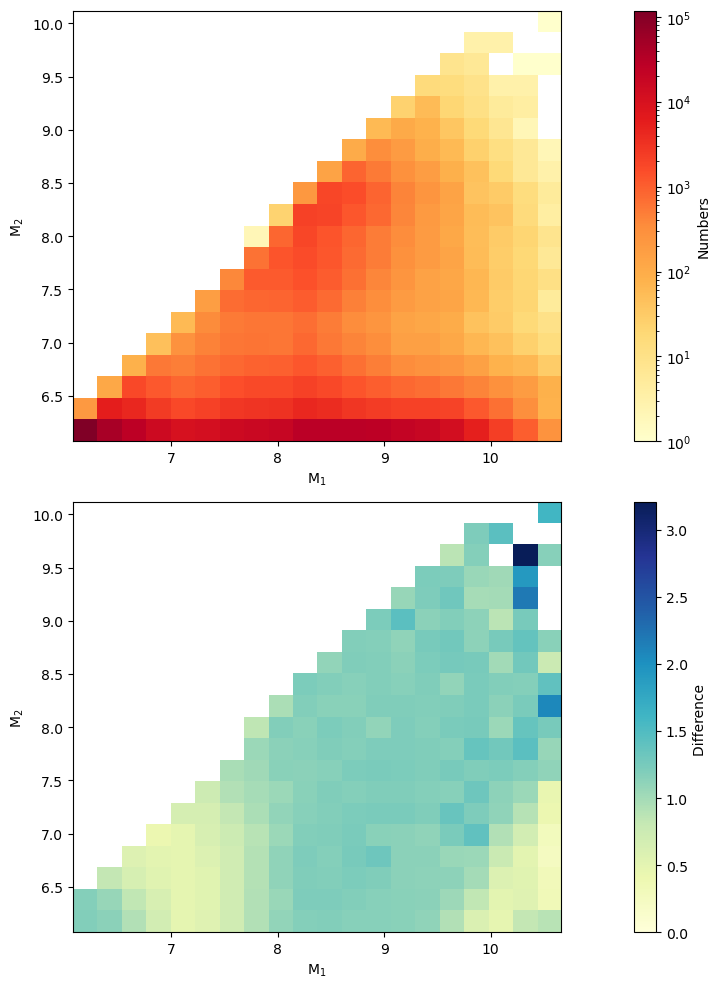

: 

In [ ]:
avg_hist(np.log10(M_1), np.log10(M_2),np.array(snr_tng300_stoch)/snr_tng300,labelx='M$_1$',labely='M$_2$',labelz='Difference ', logweight=False,vmin=0,vmax=None)

In [ ]:
# snr_tng300_wt_stoch=SNR_calc(**pop_1)
# np.save('snr_tng300_wt_stoch.npy',snr_tng300_wt_stoch)
snr_tng300_wt_stoch=np.load('snr_tng300_wt_stoch.npy')

: 

/tmp/ipykernel_2027/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


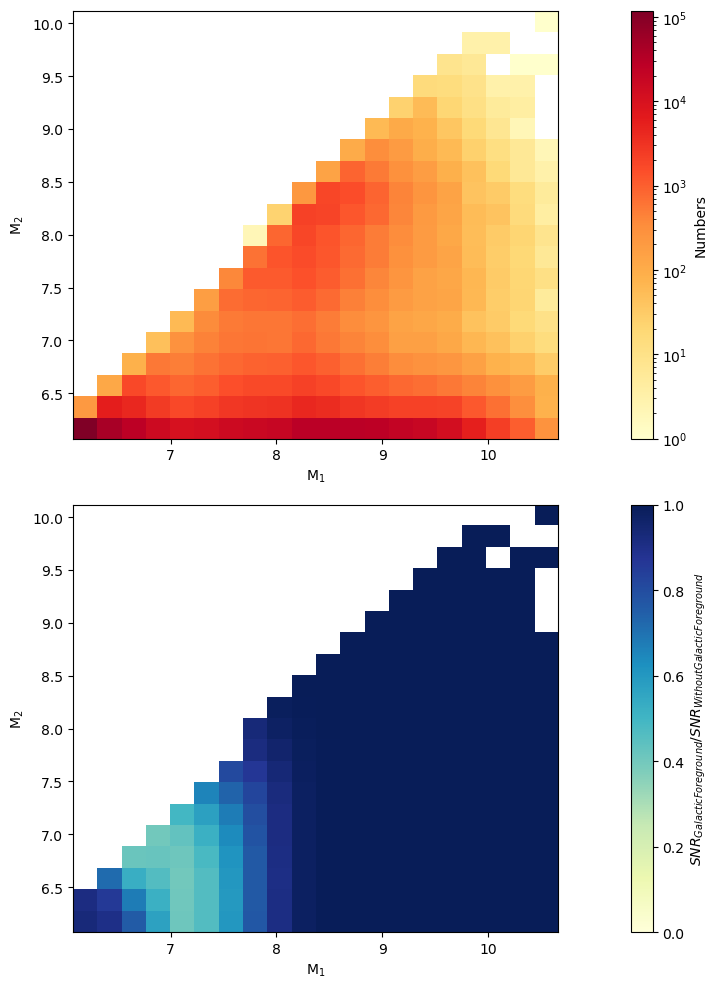

: 

In [ ]:
avg_hist(np.log10(M_1), np.log10(M_2),np.array(snr_tng300_stoch)/snr_tng300_wt_stoch,labelx='M$_1$',labely='M$_2$',labelz='$SNR_{GalacticForeground}/SNR_{WithoutGalacticForeground}$', logweight=False,vmin=0,vmax=1)

In [ ]:
# np.max(np.array(snr_tng300_stoch)/snr_tng300)

: 

/tmp/ipykernel_2027/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


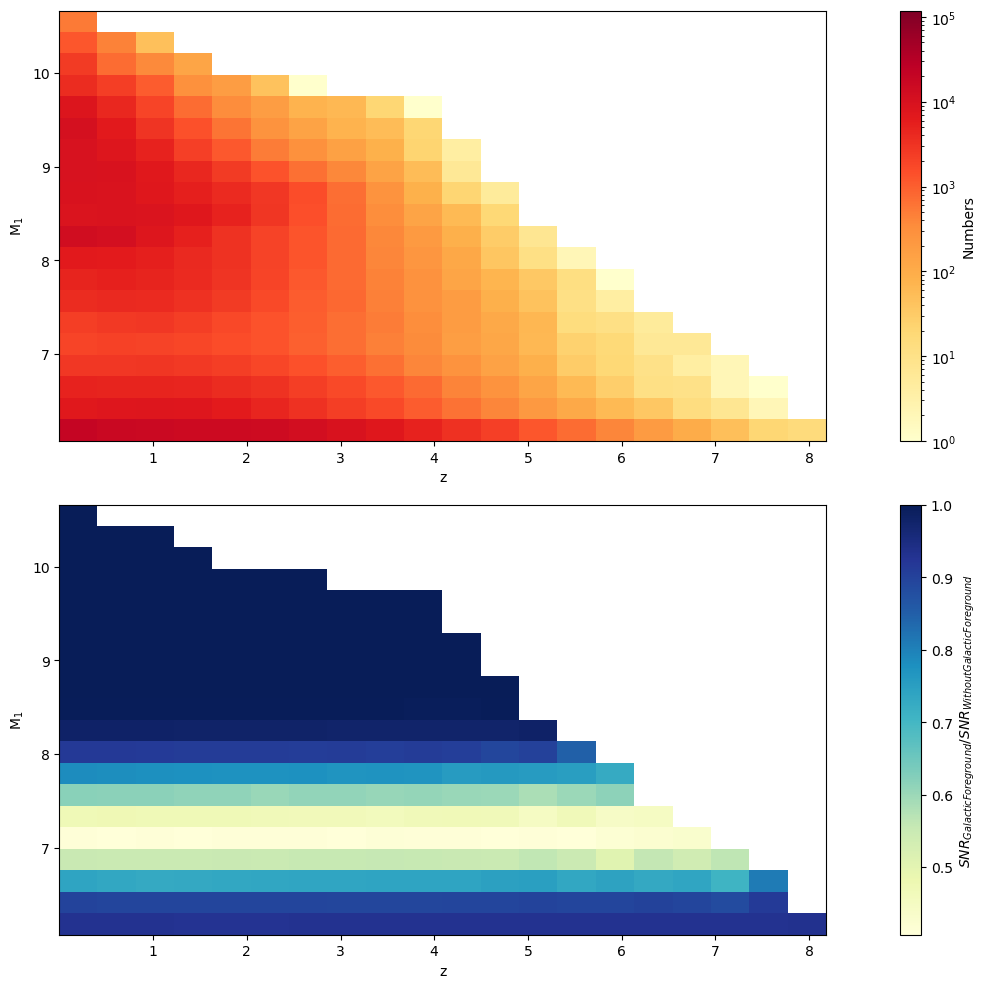

: 

In [ ]:
avg_hist(z,np.log10(M_1),np.array(snr_tng300_stoch)/np.array(snr_tng300_wt_stoch),labelx='z',labely='M$_1$',labelz='$SNR_{GalacticForeground}/SNR_{WithoutGalacticForeground}$', logweight=False,vmin=None,vmax=None)

/tmp/ipykernel_2027/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


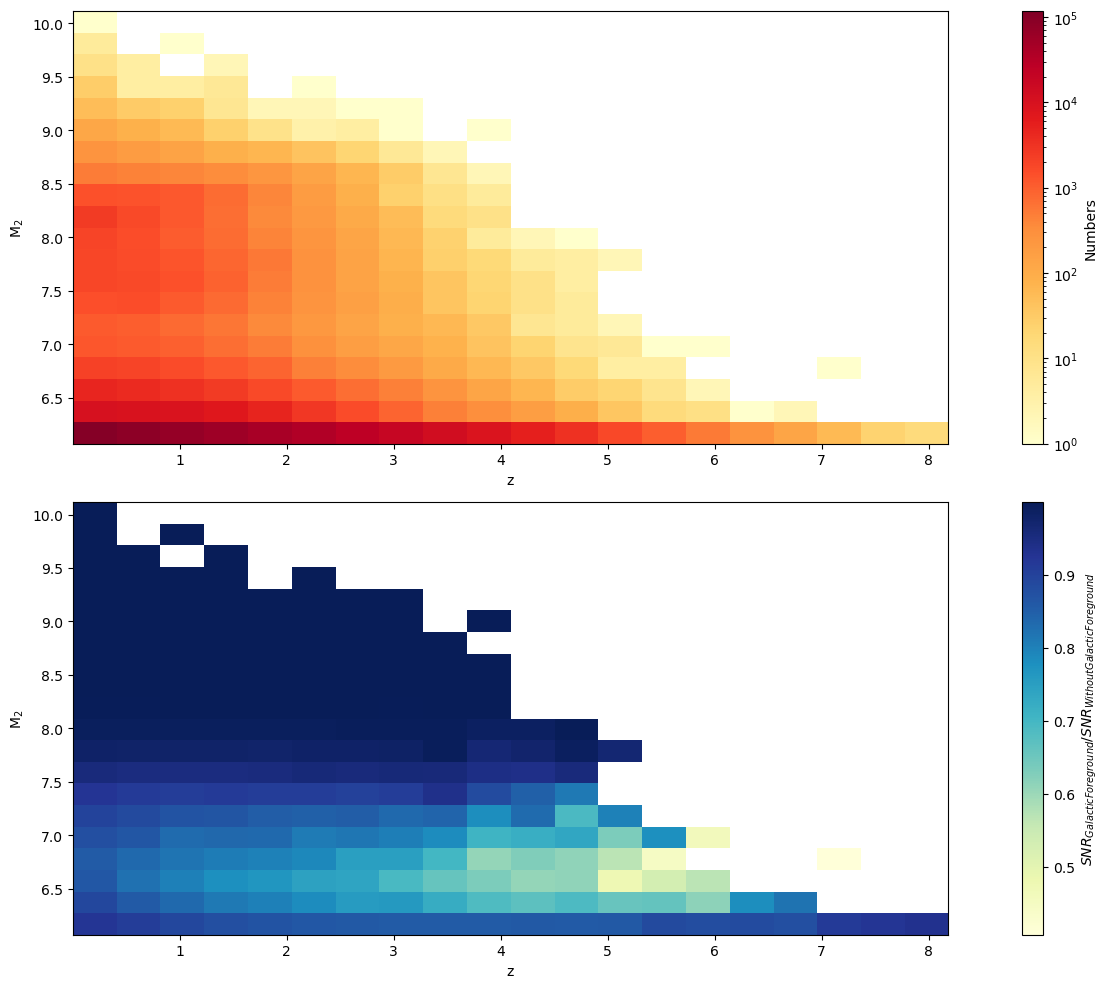

: 

In [ ]:
avg_hist(z,np.log10(M_2),np.array(snr_tng300_stoch)/np.array(snr_tng300_wt_stoch),labelx='z',labely='M$_2$',labelz='$SNR_{GalacticForeground}/SNR_{WithoutGalacticForeground}$', logweight=False,vmin=None,vmax=None)

# Spin Measurements  

We are trying to include spin for the BH Mergers 

In [ ]:
# pop_A=random_pop()

: 

In [ ]:
# with open('pop_A.npy', 'wb') as f:
#     np.save(f, pop_A, allow_pickle=True)

: 

In [ ]:
# A_params=draw_params(**pop_A)

: 

In [ ]:
# with open('A_params.npy', 'wb') as f:
#     np.save(f, A_params, allow_pickle=True)

: 

## pop_A

In [ ]:
with open('A_params.npy', 'rb') as f:
    A_parmas = np.load(f, allow_pickle=True).item()

: 

In [ ]:
with open('pop_A.npy', 'rb') as f:
    pop_A = np.load(f, allow_pickle=True).item()

NameError: name 'np' is not defined

: 

In [ ]:
# m1A=np.array(A_params['m1'])
# m2A=np.array(A_params['m2'])
# zA=np.array(A_params['z'])

m1A=np.array(pop_A['m1'])
m2A=np.array(pop_A['m2'])
z_A=np.array(pop_A['z'])


: 

In [ ]:
# snrA_s00=SNR_calc_stoch(**A_params,chi1=np.full(len(m1A),0.0), chi2=np.full(len(m2A), 0.0))
# snrA_s07=SNR_calc_stoch(**A_params,chi1=np.full(len(m1A),0.7), chi2=np.full(len(m2A), 0.7))
# snrA_s08= SNR_calc_stoch(**A_params,chi1=np.full(len(m1A),0.8), chi2=np.full(len(m2A), 0.8))

: 

In [ ]:
# np.save('snrA_s00.npy',snrA_s00)
# np.save('snrA_s07.npy',snrA_s07)
# np.save('snrA_s08.npy',snrA_s08)

snrA_s00=np.load('snrA_s00.npy')
snrA_s07=np.load('snrA_s07.npy')
snrA_s08=np.load('snrA_s08.npy')

: 

In [ ]:
snrA_s00=np.array(snrA_s00)
snrA_s07=np.array(snrA_s07)
snrA_s08=np.array(snrA_s08)
mask_s00=(snrA_s00>5)

: 

/tmp/ipykernel_2174/4001164011.py:11: RuntimeWarning: divide by zero encountered in log10
  z=np.log10(z)
/tmp/ipykernel_2174/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


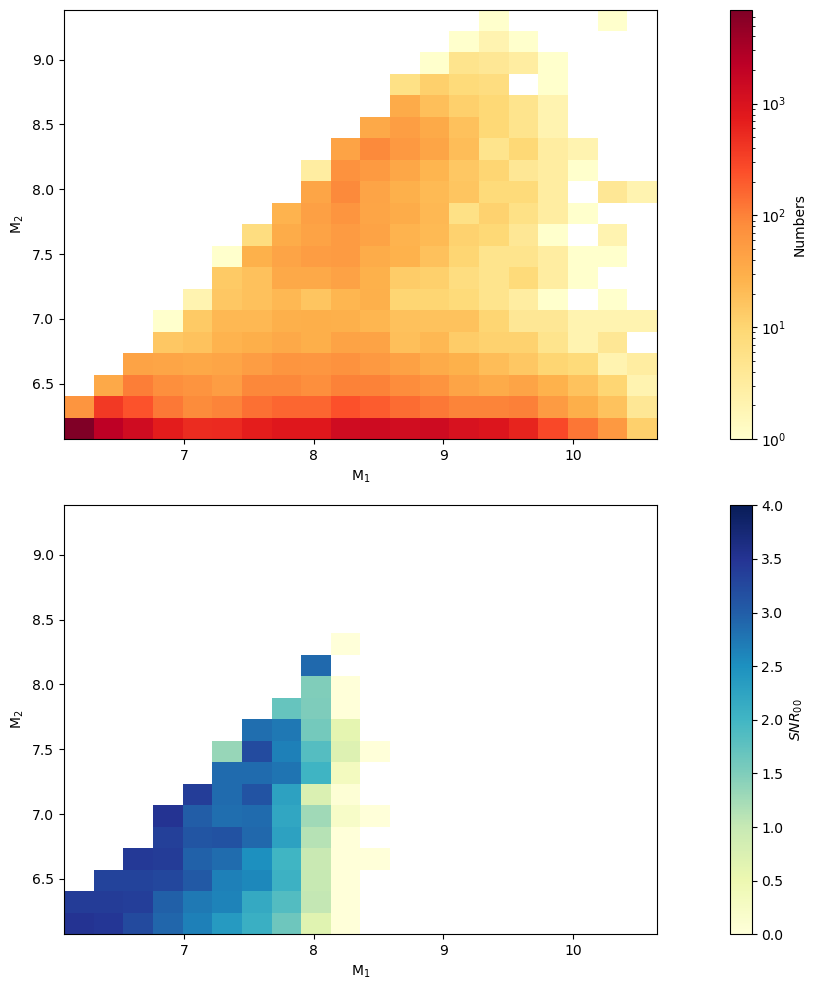

: 

In [ ]:
# avg_hist(np.log10(m1A[mask]),np.log10(m2A[mask]),np.array(zA[mask]),labelx='M$_1$',labely='M$_2$',labelz='$z$', logweight=False,vmin=None,vmax=None)
avg_hist(np.log10(m1A),np.log10(m2A),np.array(snrA_s00),labelx='M$_1$',labely='M$_2$',labelz='$SNR_{00}$', logweight=True,vmin=0,vmax=4)

I dont know why it is showing only a certain part of the graph

/tmp/ipykernel_2174/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


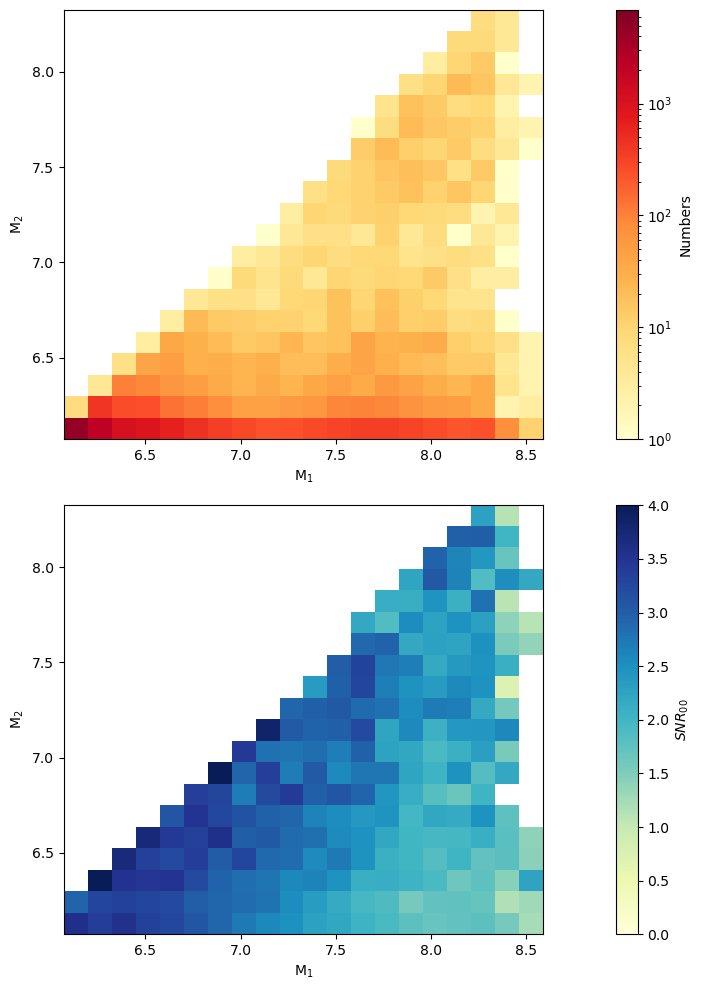

: 

In [ ]:
avg_hist(np.log10(m1A[mask_s00]),np.log10(m2A[mask_s00]),np.array(snrA_s00[mask_s00]),labelx='M$_1$',labely='M$_2$',labelz='$SNR_{00}$', logweight=True,vmin=0,vmax=4)

/tmp/ipykernel_2174/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


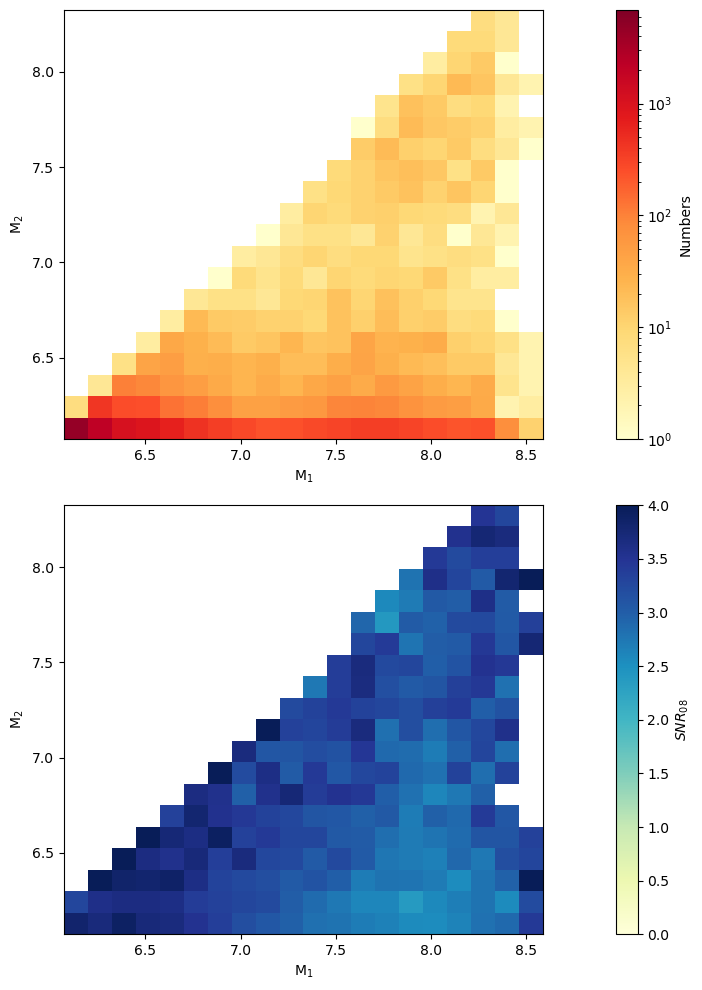

: 

In [ ]:
avg_hist(np.log10(m1A[mask_s00]),np.log10(m2A[mask_s00]),np.array(snrA_s08[mask_s00]),labelx='M$_1$',labely='M$_2$',labelz='$SNR_{08}$', logweight=True,vmin=0,vmax=4)

<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2226/2518901390.py:4: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('M$_1$[$M_\odot$]')


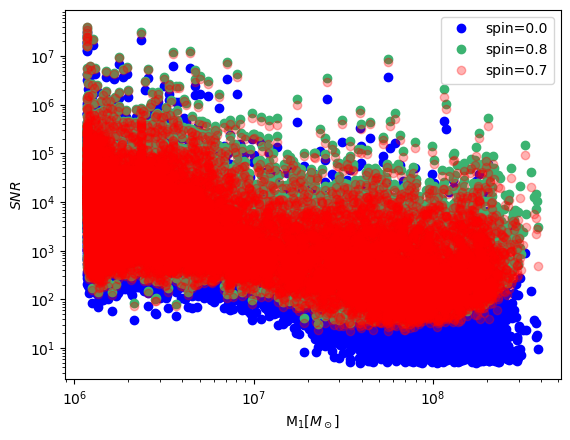

: 

In [ ]:
plt.loglog(m1A[mask_s00],snrA_s00[mask_s00],'o',c='blue',label='spin=0.0')
plt.loglog(m1A[mask_s00],snrA_s08[mask_s00],'o',c='mediumseagreen',alpha=1, label='spin=0.8')
plt.loglog(m1A[mask_s00],snrA_s07[mask_s00],'o',c='red',alpha=.3,label='spin=0.7')
plt.xlabel('M$_1$[$M_\odot$]')
plt.ylabel('$SNR$')
plt.legend()


<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_1706/2587793750.py:4: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('M$_1$[$M_\odot$]')


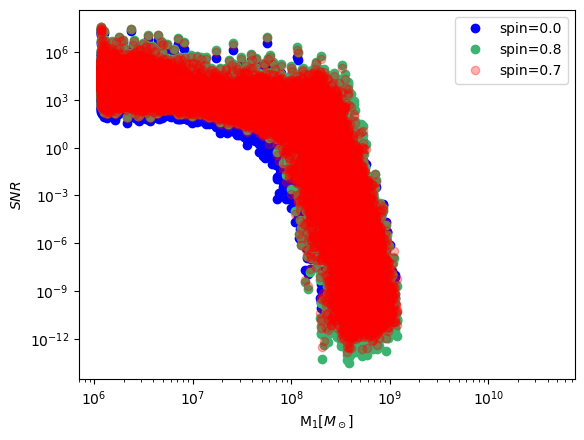

: 

In [ ]:
plt.loglog(m1A,snrA_s00,'o',c='blue',label='spin=0.0')
plt.loglog(m1A,snrA_s08,'o',c='mediumseagreen',alpha=1, label='spin=0.8')
plt.loglog(m1A,snrA_s07,'o',c='red',alpha=.3,label='spin=0.7')
plt.xlabel('M$_1$[$M_\odot$]')
plt.ylabel('$SNR$')
plt.legend()

<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_1706/2182101036.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('M$_1$[$M_\odot$]')


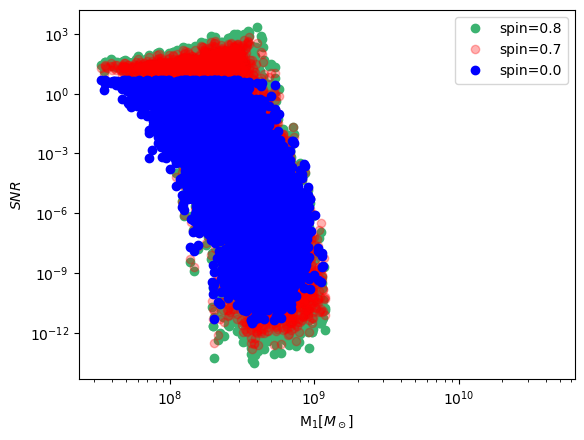

: 

In [ ]:
undetect=(snrA_s00<5)

plt.loglog(m1A[undetect],snrA_s08[undetect],'o',c='mediumseagreen',alpha=1, label='spin=0.8')
plt.loglog(m1A[undetect],snrA_s07[undetect],'o',c='red',alpha=.3,label='spin=0.7')
plt.loglog(m1A[undetect],snrA_s00[undetect],'o',c='blue',label='spin=0.0')
plt.xlabel('M$_1$[$M_\odot$]')
plt.ylabel('$SNR$')
plt.legend()

/tmp/ipykernel_1706/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


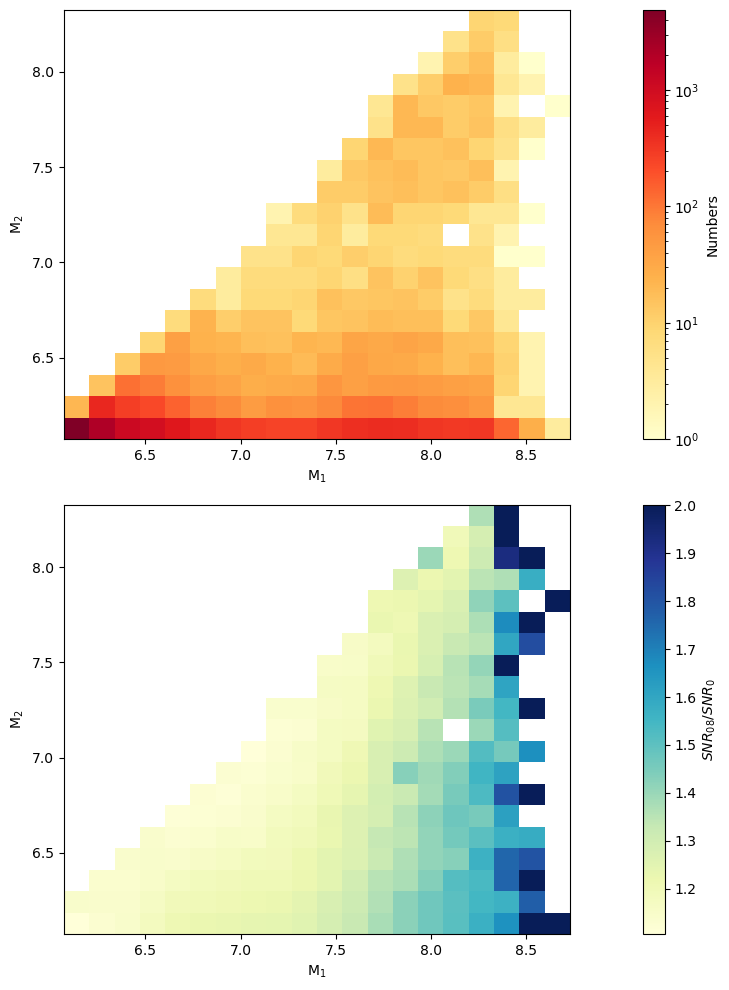

: 

In [ ]:
avg_hist(np.log10(m1A[mask_s00]),np.log10(m2A[mask_s00]),np.array(snrA_s08[mask_s00])/np.array(snrA_s07[mask_s00]),labelx='M$_1$',labely='M$_2$',labelz='$SNR_{08}/SNR_{0}$', logweight=False,vmin=None,vmax=2)

/tmp/ipykernel_1706/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


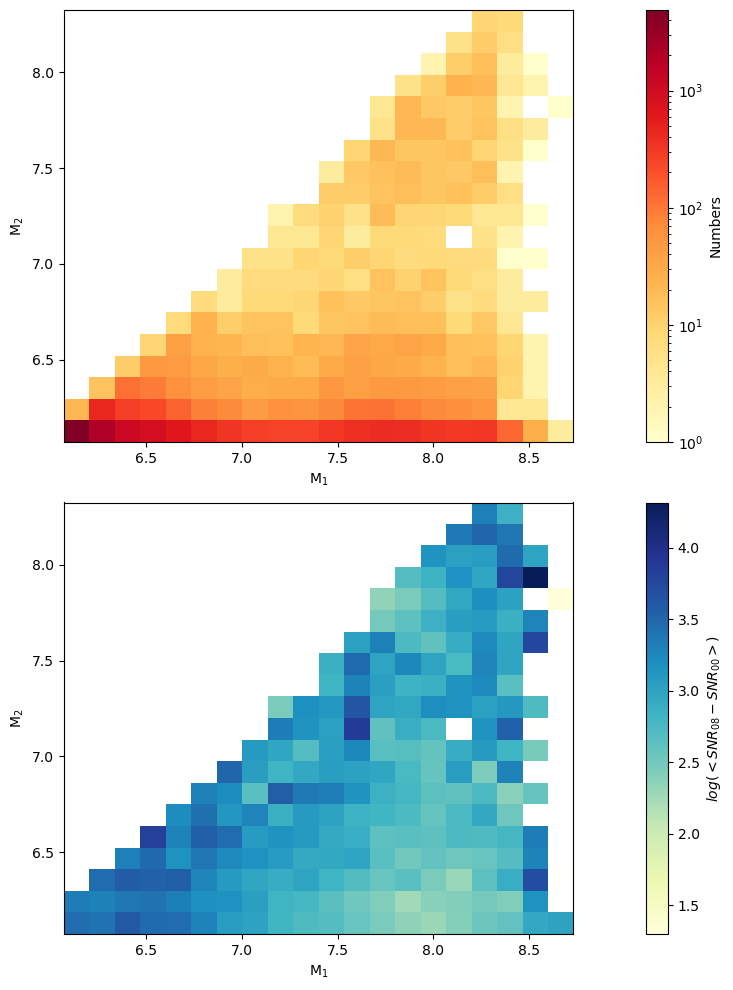

: 

In [ ]:
avg_hist(np.log10(m1A[mask_s00]),np.log10(m2A[mask_s00]),snrA_s08[mask_s00]-snrA_s00[mask_s00],labelx='M$_1$',labely='M$_2$',labelz='$log(<SNR_{08}-SNR_{00}>)$', logweight=True,vmin=None,vmax=None)

/tmp/ipykernel_1600/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


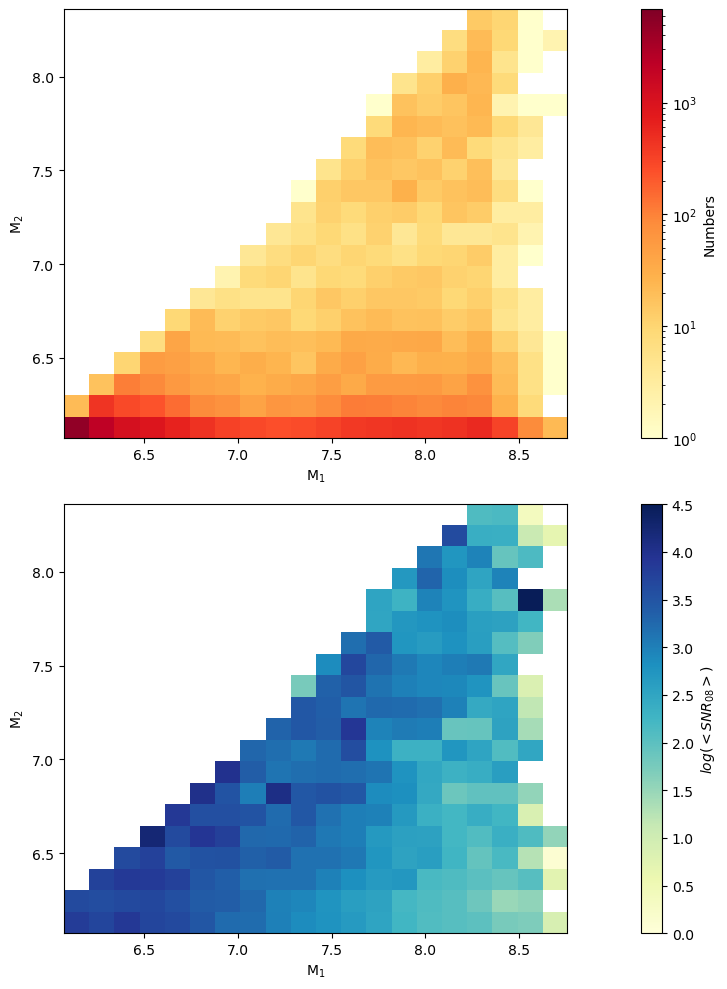

: 

In [ ]:
mask_s08=(snrA_s08>1)
avg_hist(np.log10(m1A[mask_s08]),np.log10(m2A[mask_s08]),snrA_s08[mask_s08],labelx='M$_1$',labely='M$_2$',labelz='$log(<SNR_{08}>)$', logweight=True,vmin=0,vmax=4.5)

/tmp/ipykernel_1706/4001164011.py:11: RuntimeWarning: divide by zero encountered in log10
  z=np.log10(z)
/tmp/ipykernel_1706/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


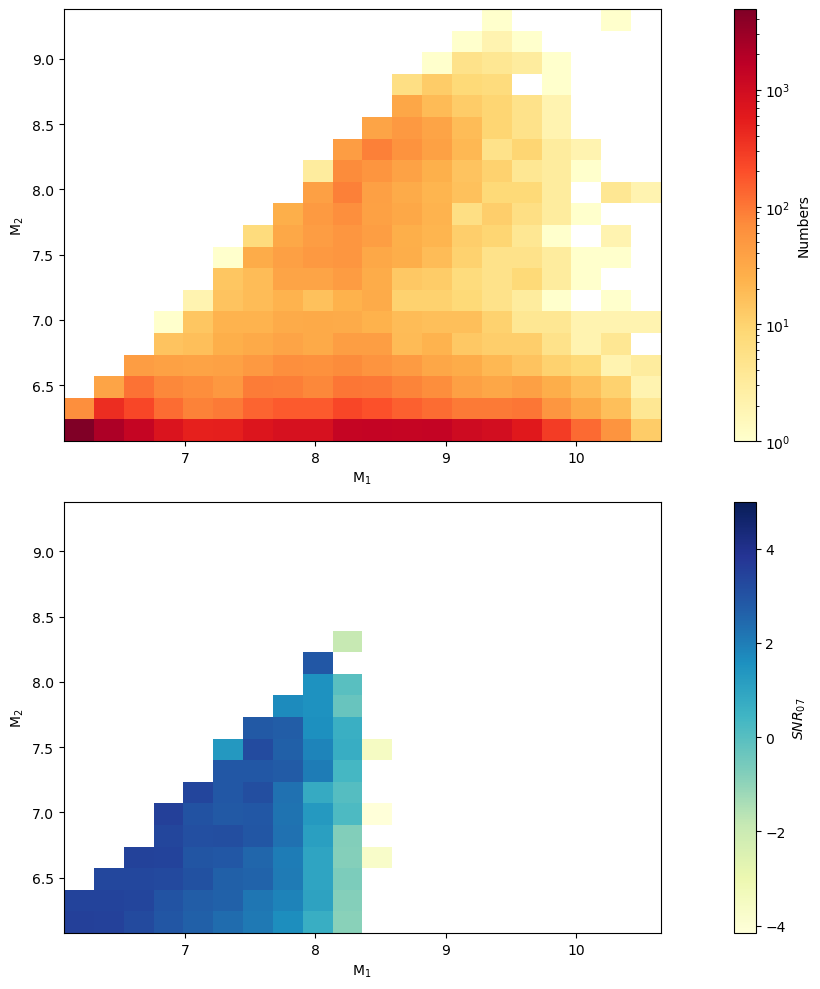

: 

In [ ]:
avg_hist(np.log10(m1A),np.log10(m2A),snrA_s00,labelx='M$_1$',labely='M$_2$',labelz='$SNR_{07}$', logweight=True,vmin=None,vmax=5)

/tmp/ipykernel_1706/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


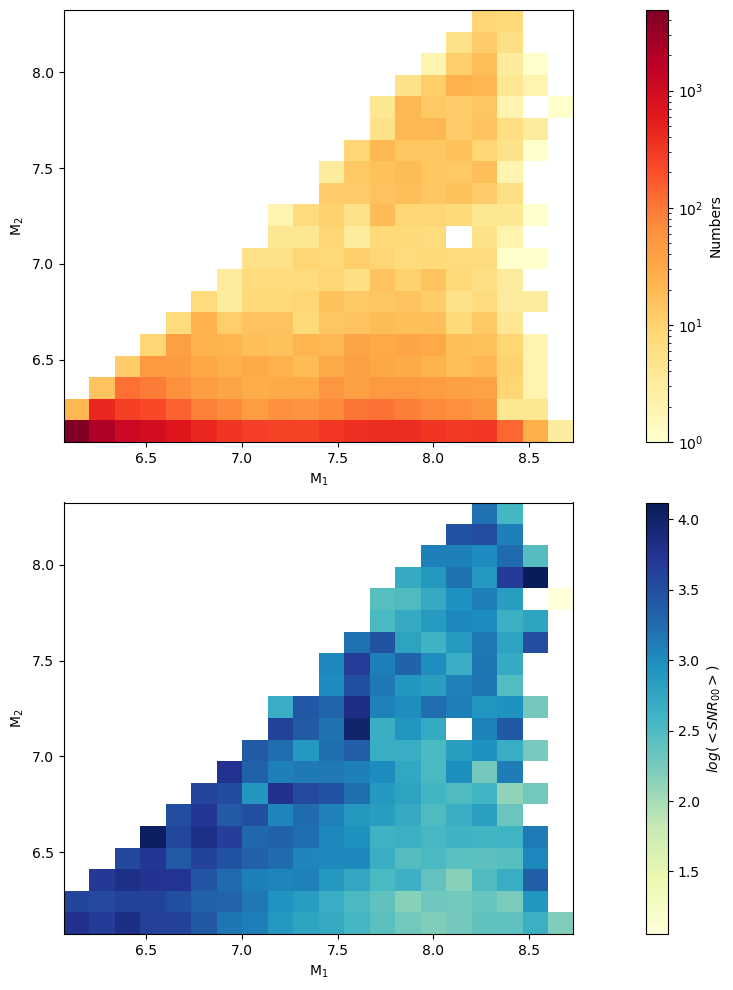

: 

In [ ]:
avg_hist(np.log10(m1A[mask_s00]),np.log10(m2A[mask_s00]),snrA_s07[mask_s00],labelx='M$_1$',labely='M$_2$',labelz='$log(<SNR_{00}>)$', logweight=True,vmin=None,vmax=None)

In [ ]:
len(snrA_s00[mask_s00])

18472

: 

/tmp/ipykernel_1706/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


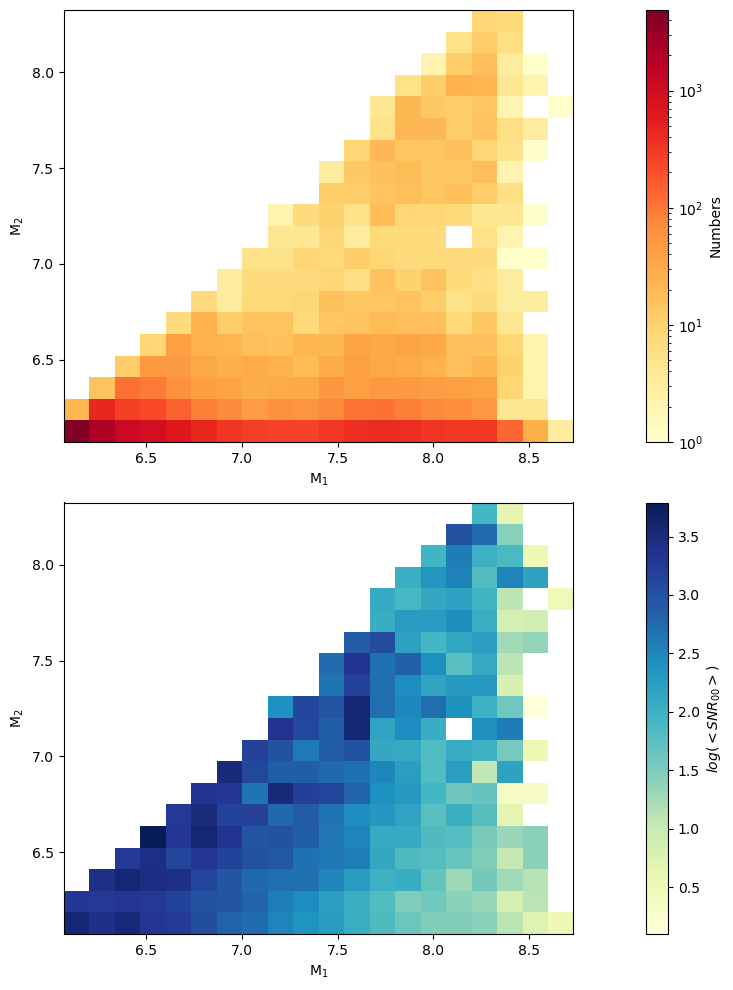

: 

In [ ]:
avg_hist(np.log10(m1A[mask_s00]),np.log10(m2A[mask_s00]),snrA_s00[mask_s00],labelx='M$_1$',labely='M$_2$',labelz='$log(<SNR_{00}>)$', logweight=True,vmin=None,vmax=None, c1=)

In [ ]:
np.array(snrA_s00)>1

array([ True,  True, False, ...,  True, False,  True])

: 

Lets do it for the whole population

In [ ]:
# pop_params=draw_params()

: 

In [ ]:
# pop_snr_s08=SNR_calc_stoch(chi1=np.full(arr_size,.8),chi2=np.full(arr_size,.8))
# np.save('pop_snr_s08.npy',pop_snr_s08)

: 

In [ ]:
pop_snr_s08= np.load('pop_snr_s08.npy')

: 

/tmp/ipykernel_1753/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


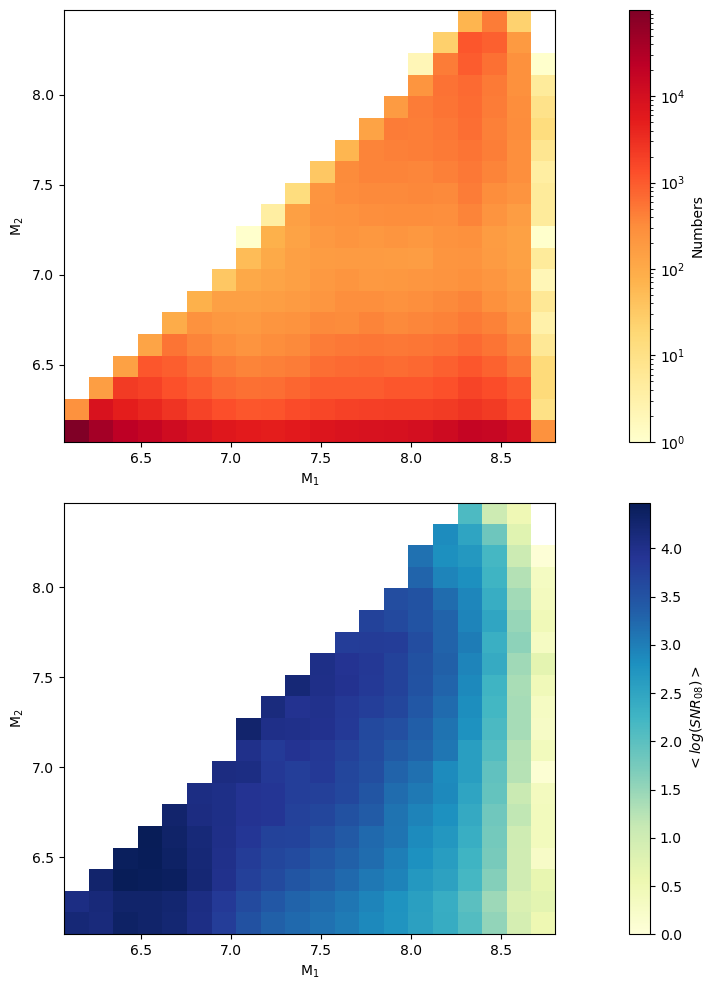

: 

In [ ]:
avg_hist(np.log10(M_1[pop_snr_s08>1]),np.log10(M_2[pop_snr_s08>1]),np.array(pop_snr_s08[pop_snr_s08>1]),labelx='M$_1$',labely='M$_2$',labelz='$<log(SNR_{08})>$', logweight=True,vmin=0,vmax=None)

In [ ]:
max(M_1[pop_snr_s08>1])

633869198.0676169

: 

In [ ]:

# Create the 2D histogram
hist, xedges, yedges = np.histogram2d(np.log10(m1A), np.log10(m2A), bins=(25, 25))

# Apply the cmin threshold manually
cmin = 5
hist[hist < cmin] = 0

: 

/tmp/ipykernel_14661/3445951163.py:4: RuntimeWarning: divide by zero encountered in log10
  pcm = ax.pcolormesh(X, Y, np.log10(hist.T), shading='auto', cmap='YlGnBu')  # Transpose `hist` because pcolormesh expects a different orientation


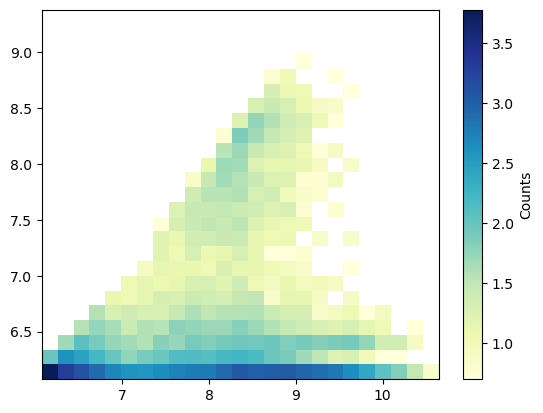

: 

In [ ]:
# Plot the 2D histogram
fig, ax = plt.subplots()
X, Y = np.meshgrid(xedges, yedges)
pcm = ax.pcolormesh(X, Y, np.log10(hist.T), shading='auto', cmap='YlGnBu')  # Transpose `hist` because pcolormesh expects a different orientation
fig.colorbar(pcm, ax=ax, label='Counts')

plt.show()


In [ ]:
def snr_percentage_hist(x, y, z1, z2, bins=(20,20),xH_lim=(6,8.6),yH_lim=(6,8.6), c1='YlOrRd', c2= 'YlGnBu',  labelx=None, labely=None, labelz=None, norm1=matplotlib.colors.LogNorm(), logweight=True, norm2=None, vmin=None,vmax=None):
    """
    Generate 2D histograms for (x, y) data with weights z1 and z2, 
    and plot the raw counts and weighted ratio (H_z2 / H_z1) side by side.
    
    Parameters:
        x, y: Input data for histogram.
        z1, z2: Weights for histogram bins.
        bins: Number of bins or bin edges.
        labelx, labely, labelz: Axis and colorbar labels for the plot.
        c1, c2: Colormaps for the two subplots.
        norm1, norm2: Normalization for the color scales.
        vmax, vmin: Optional max and min values for color scaling in the ratio plot.
        logweight: Boolean to apply log10 transformation to z1 and z2.
    """
    # Calculate the 2D histogram for counts
    H_num, xedges, yedges = np.histogram2d(x, y, bins=bins)
    
    # # Apply log transformation if requested
    # if logweight:
    #     z1 = np.log10(z1)
    #     z2 = np.log10(z2)
    
    z_mask1= (z1>5)
    z_mask2= (z2>5)
    # Create histograms with weights for z1 and z2
    H_z1, _, _ = np.histogram2d(x[z_mask1], y[z_mask1], bins=(xedges, yedges))
    H_z2, _, _ = np.histogram2d(x[z_mask2], y[z_mask2], bins=(xedges, yedges))
    
    # Apply the cmin threshold manually
    cmin = 5
    # H_z1[(H_z1 < cmin)&(H_z2 < cmin)] = 0
    # H_z2[(H_z1 < cmin)&(H_z2 < cmin)] = 0
    H_z1[(H_z1 < cmin) | (H_z2 < cmin)] = 0
    H_z2[(H_z1 < cmin) | (H_z2 < cmin)] = 0


    
    # Transpose the histograms for correct orientation
    H_num = H_num.T
    H_z1 = H_z1.T
    H_z2 = H_z2.T
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # Plot the first histogram (counts)
    im1 = ax1.imshow(H_num, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
               cmap=c1, norm=norm1)
    ax1.set_xlabel(labelx)
    ax1.set_ylabel(labely)

    # Add colorbar for the first plot
    cbar1 = plt.colorbar(im1, ax=ax1, orientation='vertical', aspect=20)
    cbar1.set_label('Numbers')

    # Plot the ratio histogram (H_z2 / H_z1)
    im2 = ax2.imshow(H_z2/H_z1*100, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
               cmap=c2, norm=norm2, vmax=vmax, vmin=vmin)
    ax2.set_xlabel(labelx, fontsize=16)
    ax2.set_xlim(xH_lim)
    ax2.set_ylim(yH_lim)
    ax2.set_ylabel(labely,fontsize=16)

    # Add colorbar for the second plot
    cbar2 = plt.colorbar(im2, ax=ax2, orientation='vertical', aspect=20)
    cbar2.set_label(labelz,fontsize=16)

    # Adjust layout to avoid overlap
    plt.tight_layout()
    plt.show()


: 

<>:1: SyntaxWarning: invalid escape sequence '\o'
<>:1: SyntaxWarning: invalid escape sequence '\o'
<>:1: SyntaxWarning: invalid escape sequence '\o'
<>:1: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_1637/4123150202.py:1: SyntaxWarning: invalid escape sequence '\o'
  snr_percentage_hist(np.log10(m1A),np.log10(m2A),snrA_s00,snrA_s08, vmax=None,c2='YlOrRd', vmin=None,labelx='$M_1[M_\odot]$',labely='$M_2[M_\odot]$',labelz=' Percentage Increase in SNR ',bins=(30,30))
/tmp/ipykernel_1637/4123150202.py:1: SyntaxWarning: invalid escape sequence '\o'
  snr_percentage_hist(np.log10(m1A),np.log10(m2A),snrA_s00,snrA_s08, vmax=None,c2='YlOrRd', vmin=None,labelx='$M_1[M_\odot]$',labely='$M_2[M_\odot]$',labelz=' Percentage Increase in SNR ',bins=(30,30))
/tmp/ipykernel_1637/2159945604.py:57: RuntimeWarning: invalid value encountered in divide
  im2 = ax2.imshow(H_z2/H_z1*100, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


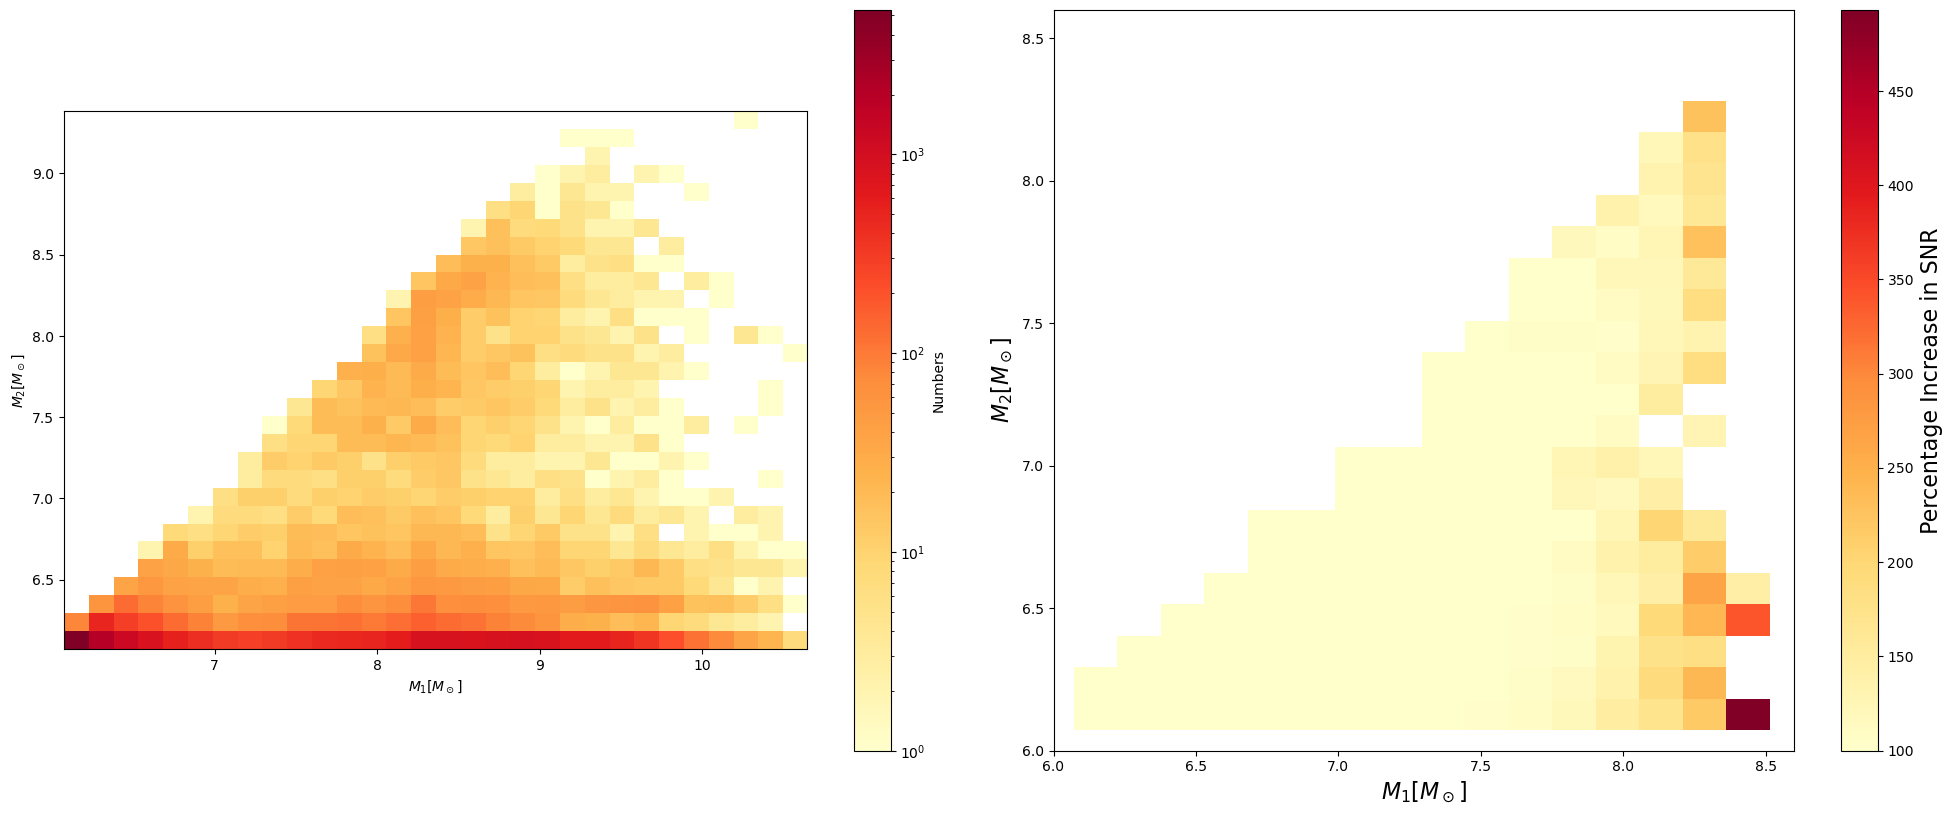

: 

In [ ]:
snr_percentage_hist(np.log10(m1A),np.log10(m2A),snrA_s00,snrA_s08, vmax=None,c2='YlOrRd', vmin=None,labelx='$M_1[M_\odot]$',labely='$M_2[M_\odot]$',labelz=' Percentage Increase in SNR ',bins=(30,30))

In [ ]:
# Change the axis RH 
# Play with vmin and vmax
# check redshift
# chirp mass 

: 

<>:1: SyntaxWarning: invalid escape sequence '\o'
<>:1: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_14661/1753748573.py:1: SyntaxWarning: invalid escape sequence '\o'
  snr_percentage_hist(z_A,np.log10(m1A),snrA_s00,snrA_s08, vmax=800, vmin=100,labelx='Redshift, $z$',labely='$M_1[M_\odot]$',labelz='Percentage',bins=(30,30),xH_lim=(0,8),yH_lim=(min(np.log10(m1A)),9))
/tmp/ipykernel_14661/801732197.py:57: RuntimeWarning: invalid value encountered in divide
  im2 = ax2.imshow(H_z2/H_z1*100, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


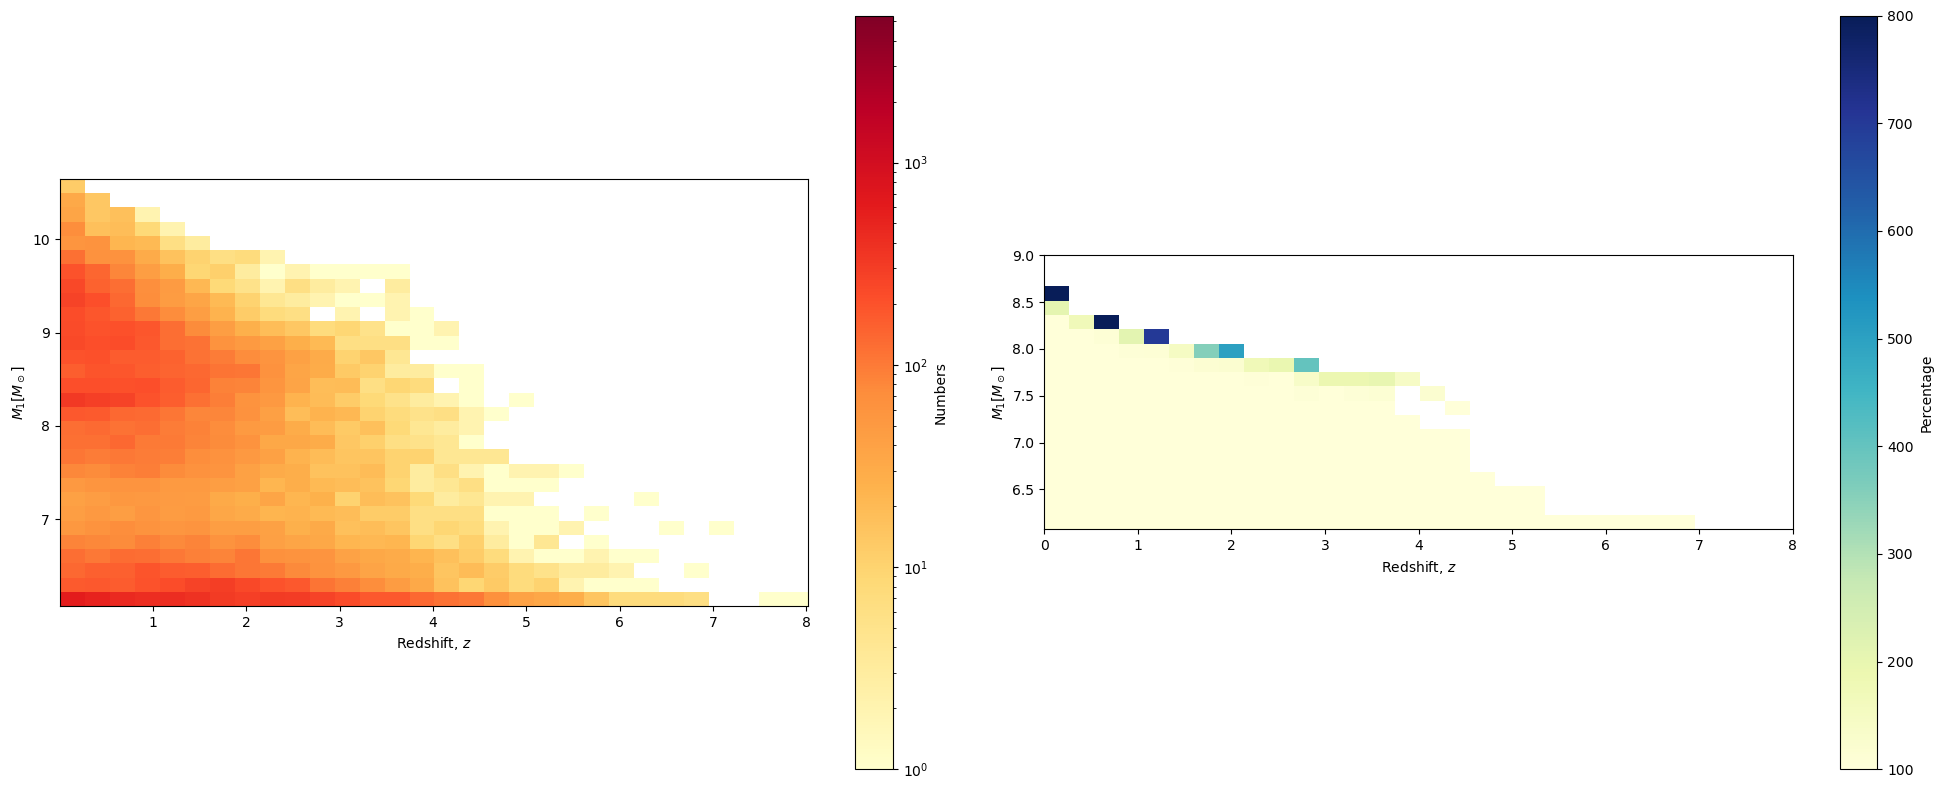

: 

In [ ]:
snr_percentage_hist(z_A,np.log10(m1A),snrA_s00,snrA_s08, vmax=800, vmin=100,labelx='Redshift, $z$',labely='$M_1[M_\odot]$',labelz='Percentage',bins=(30,30),xH_lim=(0,8),yH_lim=(min(np.log10(m1A)),9))

In [ ]:
def mu(m1=m1A,m2=m2A):
    mu=(m1*m2)**(3/5)/(m1+m2)**(1/5)
    return mu

: 

In [ ]:
muA=np.array(mu(m1A,m2A))

: 

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\o'
<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_14661/1450046742.py:1: SyntaxWarning: invalid escape sequence '\m'
  snr_percentage_hist(np.log10(muA),np.log10(m1A),snrA_s00,snrA_s08, vmax=None, vmin=None,labelx='Chirp Mass, $\mu[M_\odot]$',labely='$M_1[M_\odot]$',labelz='Percentage',bins=(30,30))
/tmp/ipykernel_14661/1450046742.py:1: SyntaxWarning: invalid escape sequence '\o'
  snr_percentage_hist(np.log10(muA),np.log10(m1A),snrA_s00,snrA_s08, vmax=None, vmin=None,labelx='Chirp Mass, $\mu[M_\odot]$',labely='$M_1[M_\odot]$',labelz='Percentage',bins=(30,30))
/tmp/ipykernel_14661/801732197.py:57: RuntimeWarning: invalid value encountered in divide
  im2 = ax2.imshow(H_z2/H_z1*100, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


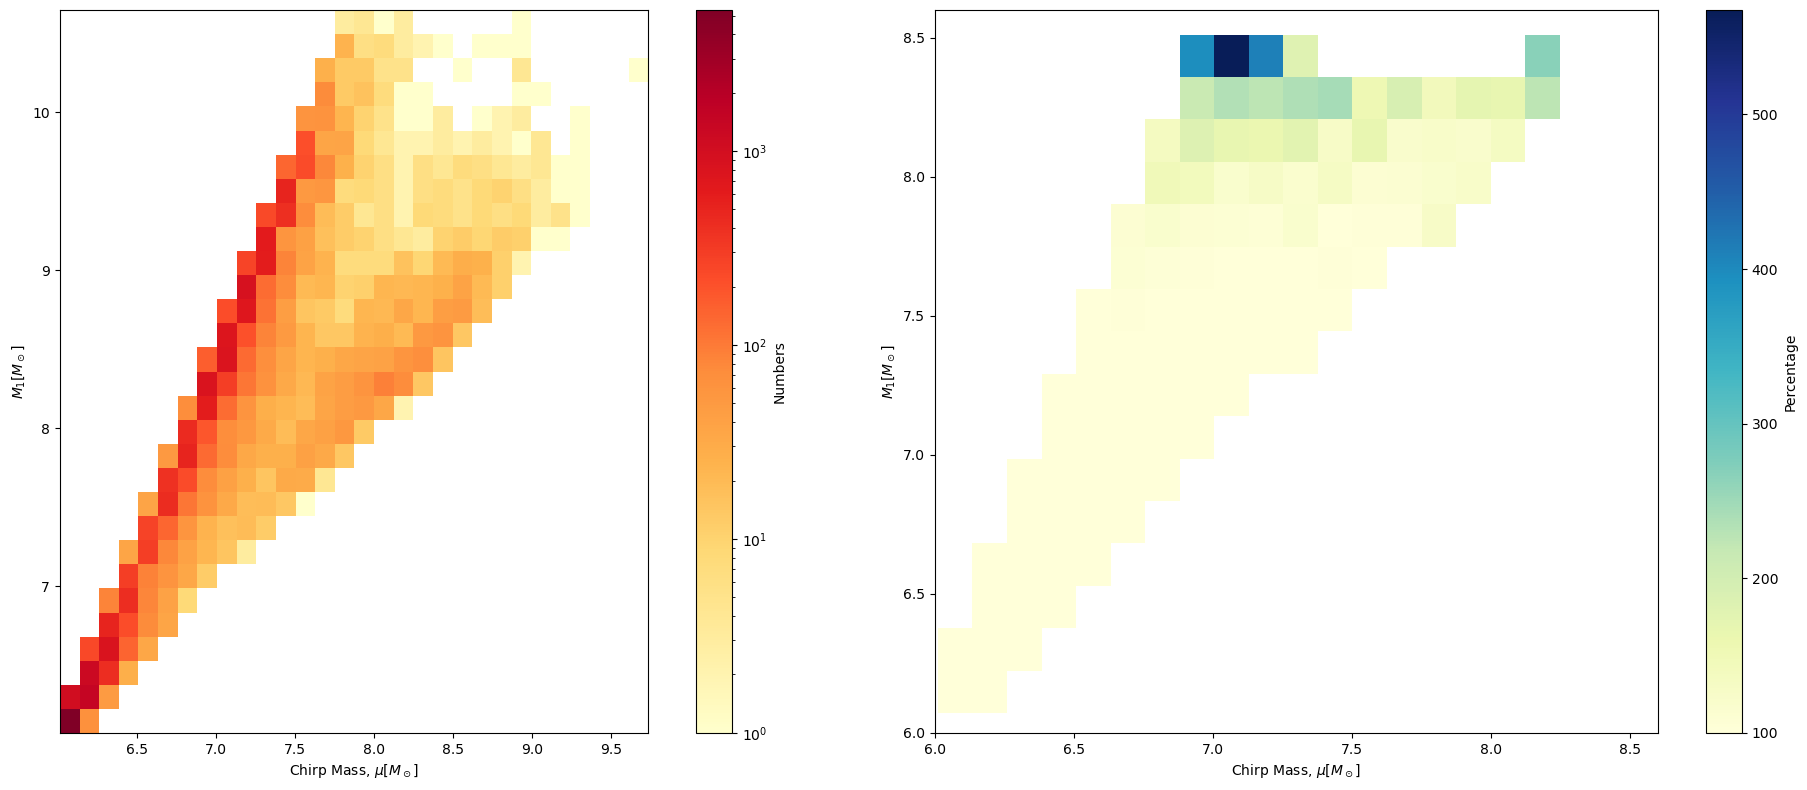

: 

In [ ]:
snr_percentage_hist(np.log10(muA),np.log10(m1A),snrA_s00,snrA_s08, vmax=None, vmin=None,labelx='Chirp Mass, $\mu[M_\odot]$',labely='$M_1[M_\odot]$',labelz='Percentage',bins=(30,30))

# Observaation Time

In [ ]:
dcosmo.luminosity_distance(3)

<Quantity 26038.68292404 Mpc>

: 

In [ ]:
obs_1 =SNR_calc_stoch(m1 = [1e6], m2 = [1e5], dist = [cosmo.luminosity_distance(3).value*1e6*PC_SI], chi1 = [0.8],
             chi2 = [0.8], phi_ref =[0.6],
             f_ref =[0.0], inc = [np.pi / 8],
             lam =[0.5], beta =[-0.7],
             psi =[4], t_ref = [1e7],
             num_elements = 1,obs=5,z=3)

: 

In [ ]:
obs_1

[565.8100130311469]

: 

In [ ]:
obs_2 =SNR_calc_stoch(m1 = [1e6], m2 = [1e5], dist = [cosmo.luminosity_distance(3)], chi1 = [0.8],
             chi2 = [0.8], phi_ref =[0.6],
             f_ref =[0.0], inc = [np.pi / 8],
             lam =[0.5], beta =[-0.7],
             psi =[4], t_ref = [1e6],
             num_elements = 1,obs=2,z=3)

: 

In [ ]:
obs_1 =SNR_calc_stoch(m1 = [1e6], m2 = [1e5], dist = [cosmo.luminosity_distance(3)], chi1 = [0.8],
             chi2 = [0.8], phi_ref =[0.6],
             f_ref =[0.0], inc = [np.pi / 8],
             lam =[0.5], beta =[-0.7],
             psi =[4], t_ref = [1e6],
             num_elements = 1,obs=1,z=3)

: 

In [ ]:
def obs_t(obs=.5,bins=5):
    t=np.linspace(0.0001,obs,bins)
    snr=[]
    for i in range(len(t)):
        snr_i=SNR_calc_stoch(m1 = [1e7], m2 = [5e6], dist = [cosmo.luminosity_distance(3).value*1e6*PC_SI], chi1 = [0.8],
                            chi2 = [0.8], phi_ref =[0.6],
                            f_ref =[0.0], inc = [np.pi / 8],
                            lam =[0.5], beta =[-0.7],
                            psi =[4], t_ref = [1e7],
                            num_elements = 1,obs=t[i],z=3)
        snr.append(snr_i)
        # print(snr_i)
    plt.scatter(t,np.log10(snr))
    return snr

: 

In [ ]:
def obs_t(obs=1/52,bins=5):
    t=np.linspace(0.0001,obs,bins)
    snr=[]
    for i in range(len(t)):
        snr_i=SNR_calc_stoch(m1 = [1e7], m2 = [5e6], dist = [cosmo.luminosity_distance(3).value*1e6*PC_SI], chi1 = [0.8],
                            chi2 = [0.8], phi_ref =[0.6],
                            f_ref =[0.0], inc = [np.pi / 8],
                            lam =[0.5], beta =[-0.7],
                            psi =[4], t_ref = [1e6],t_obs_end=t[i],z=3)
        snr.append(snr_i)
        # print(snr_i)
    plt.scatter(t,np.log10(snr))
    return snr

: 

In [ ]:
snr_i=SNR_calc_stoch(m1 = [1e6], m2 = [1e5], dist = [cosmo.luminosity_distance(3).value*1e6*PC_SI], chi1 = [0.8],
                            chi2 = [0.8], phi_ref =[0.6],
                            f_ref =[0.0], inc = [np.pi / 8],
                            lam =[0.5], beta =[-0.7],
                            psi =[4], t_ref = [1e7], t_obs_end=1,
                            num_elements = 1,z=3)
snr_i

[565.8080367353454]

: 

In [ ]:
obs_t(obs=1/52,bins=2)

IndexError: list index out of range

: 

In [ ]:
obs_t()

ValueError: Orbital information does not cover minimum (-2625645.126847187) and maximum (231.42787737958133) tf. Orbital information begins at 0.0 and ends at 158025600.0.

: 

In [ ]:
m1 = [1e6], 
m2 = [1e5], 
dist = [cosmo.luminosity_distance(3).value*1e6*PC_SI], 
chi1 = [0.8],
chi2 = [0.8], 
phi_ref =[0.6],
f_ref =[0.0], inc = [np.pi / 8],
lam =[0.5], 
beta =[-0.7],
psi =[4], 
t_ref = [1e7],
num_elements = 1,
obs=5,
z=3
length = 1024

# Setup data holders
Tobs = YRSID_SI / 12 *obs   # 1 month
dt = 10.0  # sec
N = int(Tobs / dt)
Tobs = N * dt

freqs = np.fft.rfftfreq(N, dt)
freqs=freqs[freqs>=10**(-4)]

SNR_new = []

for i in range(num_elements):
    AET_gen = tdi_wave_gen(
        m1[i],
        m2[i], 
        chi1[i],
        chi2[i],
        dist[i], 
        phi_ref[i],
        f_ref[i], 
        inc[i],
        lam[i],
        beta[i],
        psi[i],
        t_ref[i],
        t_obs_start= obs/12,
        t_obs_end=-1/52,            
        length=1024, 
        combine=False,  # TODO: check this
        direct=False,
        fill=True,
        squeeze=True,
        freqs=freqs
    )
    
    data = DataResidualArray(AET_gen[0], f_arr=freqs)
    sens_mat = AET1SensitivityMatrix(data.f_arr,stochastic_params=(4.0 * YRSID_SI,))
    analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
    snr = analysis.snr()
    SNR_new.append(snr)

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (732593431.py, line 7)

: 

In [ ]:
obs_1 =SNR_calc_stoch(m1 = [1e6], m2 = [1e5], dist = [cosmo.luminosity_distance(3)*1e6*PC_SI], chi1 = [0.8],
             chi2 = [0.8], phi_ref =[0.6],
             f_ref =[0.0], inc = [np.pi / 8],
             lam =[0.5], beta =[-0.7],
             psi =[4], t_ref = [1e7],
             num_elements = 1,obs=1,z=3)
obs_1


[128.97473371727156]

: 

In [ ]:
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False))

: 

In [ ]:
f_ref = 0.0  # let phenom codes set f_ref -> fmax = max(f^2A(f))
phi_ref = 0.0 # phase at f_ref
m1 = 1e7
m2 = 5e6
a1 = 0.2
a2 = 0.4
dist = 18e3  * PC_SI * 1e6 # 3e3 in Mpc
inc = np.pi/3.
beta = np.pi/4.  # ecliptic latitude
lam = np.pi/5.  # ecliptic longitude
psi = np.pi/6.  # polarization angle
t_ref = 0.5 * YRSID_SI  # t_ref  (in the SSB reference frame)

# frequencies to interpolate to
freq_new = np.logspace(-4, 0, 10000)
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]


: 

Text(0, 0.5, '$\\tilde{h}(f)$ (Hz$^{-1/2}$)')

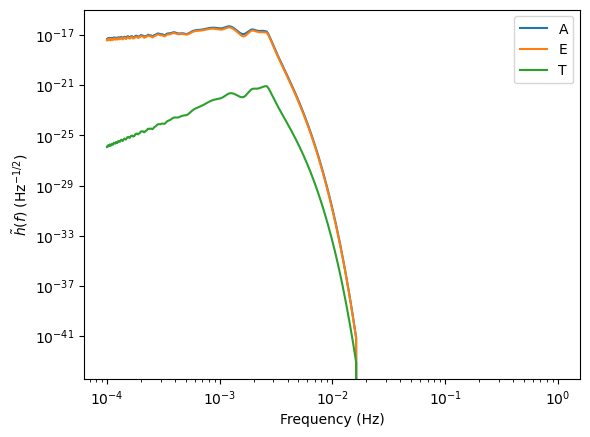

: 

In [ ]:
wave = wave_gen(m1, m2, a1, a2,
                          dist, phi_ref, f_ref, inc, lam,
                          beta, psi, t_ref, freqs=freq_new,
                          modes=modes, direct=False, fill=True, squeeze=True, length=1024)[0]

for i, let in enumerate(["A", "E", "T"]):
    plt.loglog(freq_new, np.abs(wave[i]), label=let)
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$\tilde{h}(f)$ (Hz$^{-1/2}$)")

[0. 0. 0. ... 0. 0. 0.]


Text(0, 0.5, '$\\tilde{h}(f)$ (Hz$^{-1/2}$)')

/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  func(*args, **kwargs)


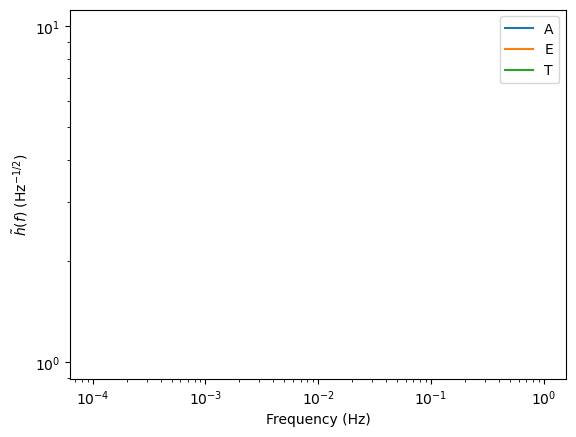

: 

In [ ]:
# start at the beginning of observation
t_obs_start = 0.0

t_obs_end = 1/52 # 1 day before merger

wave = wave_gen(m1, m2, a1, a2,
                          dist, phi_ref, f_ref, inc, lam,
                          beta, psi, t_ref, freqs=freq_new,
                          modes=modes, direct=False, fill=True, squeeze=True, length=1024, t_obs_start=t_obs_start, t_obs_end=t_obs_end)[0]
print(np.abs(wave[0]))

for i, let in enumerate(["A", "E", "T"]):
    plt.loglog(freq_new, np.abs(wave[i]), label=let)
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$\tilde{h}(f)$ (Hz$^{-1/2}$)")

In [ ]:
np.max(t_obs_end)

0.49726219690801376

: 

In [ ]:
f_ref = 0.0  # let phenom codes set f_ref -> fmax = max(f^2A(f))
phi_ref = 0.0 # phase at f_ref
m1 = 1e6
m2 = 5e5
a1 = 0.2
a2 = 0.4
dist = 18e3  * PC_SI * 1e6 # 3e3 in Mpc
inc = np.pi/3.
beta = np.pi/4.  # ecliptic latitude
lam = np.pi/5.  # ecliptic longitude
psi = np.pi/6.  # polarization angle
t_ref = 0.5 * YRSID_SI 
freq_new = np.logspace(-4, 0, 10000)
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]


: 

In [ ]:
from lisatools.sources import BBHCalculationController

: 

In [ ]:
SNR_calc= BBHCalculationController(m1, m2, a1, a2,
                          dist, phi_ref, f_ref, inc, lam,
                          beta, psi, t_ref,)

TypeError: CalculationController.__init__() takes from 6 to 7 positional arguments but 13 were given

: 

In [ ]:
x=m1A
y=m2A
plt.plot(x,y)

NameError: name 'm1A' is not defined

: 

In [ ]:
from lisatools.sources.bbh import BBHSNRWaveform

: 

In [ ]:
wave=BBHSNRWaveform()

TypeError: BBHSNRWaveform.__init__() takes from 1 to 3 positional arguments but 13 were given

: 

In [ ]:
wave(m1, m2, a1, a2,
    dist, phi_ref, f_ref, inc, lam,
    beta, psi, t_ref)

TypeError: 'numpy.ndarray' object is not callable

: 

In [ ]:
print(type(wave))

<class 'numpy.ndarray'>


: 

In [ ]:
(print(callable(wave)))

False


: 

In [ ]:
output = wave(m1, m2, a1, a2,
              dist, phi_ref, f_ref, inc, lam,
              beta, psi, t_ref,
              return_array=True, mf_min=0.0001, mf_max=0.6)


TypeError: 'numpy.ndarray' object is not callable

: 

In [ ]:
from lisatools.sources.bbh import BBHSNRWaveform

wave = BBHSNRWaveform(
    bbh_waveform_kwargs={'run_phenomd': False},
    response_kwargs={'TDItag': 'AET', 'tdi2': True}
)


: 

In [ ]:
print(callable(wave))  # Should return True


True


: 

In [ ]:
output = wave(m1, m2, a1, a2,
              dist, phi_ref, f_ref, inc, lam,
              beta, psi, t_ref,
              return_array=True, mf_min=0.0001, mf_max=0.6)


: 

In [ ]:
output

array([[ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j, ...,
         2.29030175e-28+4.45700458e-28j,  9.08325392e-29+3.75488764e-28j,
         2.75721360e-28+1.10959265e-28j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j, ...,
         3.51872307e-28-1.63072127e-28j,  2.93137118e-28-5.83385243e-29j,
         9.45067650e-29-2.09542010e-28j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j, ...,
         3.35009949e-31-5.32462491e-31j,  3.56705038e-31-3.47035341e-31j,
        -5.92958211e-32-3.88389314e-31j]], shape=(3, 1024))

: 

In [ ]:
A, E, T = wave(
    m1, m2, a1, a2,
    dist, phi_ref, f_ref, inc, lam,
    beta, psi, t_ref,
    return_array=False,  # Change to True if you want an array output
    mf_min=0.0001, mf_max=0.6
)

# Check output
print(A.shape, E.shape, T.shape)


(1024,) (1024,) (1024,)


: 

In [ ]:
m1_j=np.load('M_1_jillia.npy')
z_j=np.load('Z_jillian.npy')
m2_j=np.load('M_2_jillia.npy')

: 

# TNG vs Jillian

## Imports for TNG & Jillian

In [13]:
### Jillian data
snr_j=np.load('snr_Jillian.npy')
m1_j=np.load('M_1_jillia.npy')
z_j=np.load('Z_jillian.npy')
m2_j=np.load('M_2_jillia.npy')
d_l_j=np.load('d_l_jillian.npy')

In [18]:
### TNG300 data
with open('A_params.npy', 'rb') as f:
    A_parmas = np.load(f, allow_pickle=True).item()
with open('pop_A.npy', 'rb') as f:
    pop_A = np.load(f, allow_pickle=True).item()



snrA_s08=np.load('snrA_s08.npy')
m1A=np.array(pop_A['m1'])
m2A=np.array(pop_A['m2'])
z_A=np.array(pop_A['z'])



ValueError: x and y must be the same size

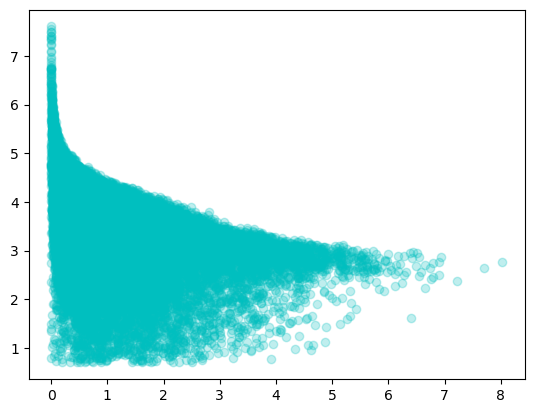

: 

In [ ]:
detect=snrA_s08>5

plt.scatter(z_A[detect],np.log10(snrA_s08[detect]),label='TNG-300',c='c',alpha=.25)
plt.scatter(z_j,np.log10(snr_j),label='Jillian',c='darkred',alpha=.5)
plt.xlabel('Redshift')
plt.ylabel('$SNR$')
x_mean_plotter(z_A[detect],np.log10(snrA_s08[detect]),color='navy',xbins=20,label='<SNR> for TNG',xgmean=False)
x_mean_plotter(z_j,np.log10(snr_j),xbins=10,label='<SNR> for Jillian',xgmean=False)
plt.legend()




In [ ]:
### redshift dependence is consistent 

: 

Text(0, 0.5, 'SNR')

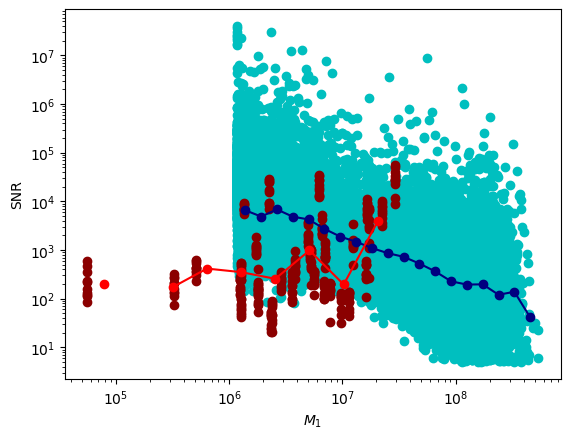

: 

In [ ]:
plt.loglog(m1A[detect],snrA_s08[detect],'o',c='c',alpha=1, label='spin=0.8')
plt.loglog(m1_j,snr_j,'o',c='darkred')
# plt.ylim(5)
x_mean_plotter(m1A[detect],snrA_s08[detect],xbins=20,color='navy')
x_mean_plotter(m1_j,snr_j,color='red')
plt.xlabel('$M_1$')
plt.ylabel("SNR")

: 